# MegaGO Exploration: Module Network Visualization

This notebook builds a single **top 30 BP-term** MegaGO clustering for Lloyd-Price modules and uses that clustering to drive downstream network visualizations.

The MegaGO similarity matrix is computed from the top 30 enriched **Biological Process (BP)** terms per module.
Modules are colored by **MegaGO-based hierarchical clusters** and will be annotated with cluster-level labels generated downstream.

**Prerequisites:**
- Run `Module_Overview_Generator.ipynb` first to generate the module overview CSV
- Cytoscape must be running for the Cytoscape visualization sections
- MegaGO installed in `LemonIte` conda environment

**Required Input Files:**
- `Module_Overview_Complete.csv` - Generated by Module_Overview_Generator.ipynb
- `Enrichr_top_10_enriched_pathways_up_per_module.csv` - Available EnrichR pathway enrichment data

In [4]:
# Import Required Libraries
import pandas as pd
import numpy as np
import os
import sys
import shutil
import warnings
import re
import glob
import subprocess
import itertools
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

In [5]:
# overlap adjustment helper available globally
def adjust_positions_to_avoid_overlap(pos, min_dist=60):
    '''Ensure module nodes are not too close.'''
    moved=True
    import numpy as np, random
    while moved:
        moved=False
        items=list(pos.items())
        for i,(n1,(x1,y1)) in enumerate(items):
            if not n1.startswith('Module_'): continue
            for n2,(x2,y2) in items[i+1:]:
                if not n2.startswith('Module_'): continue
                dx=x2-x1; dy=y2-y1
                dist=np.hypot(dx,dy)
                if dist==0:
                    dx=random.uniform(-1,1); dy=random.uniform(-1,1)
                    dist=np.hypot(dx,dy)
                if dist<min_dist:
                    shift=(min_dist-dist)/2.0
                    ang=np.arctan2(dy,dx)
                    pos[n1]=(x1-shift*np.cos(ang), y1-shift*np.sin(ang))
                    pos[n2]=(x2+shift*np.cos(ang), y2+shift*np.sin(ang))
                    moved=True
    return pos



In [14]:
# Configuration

base_dir = '/home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/results/LemonTree/'
os.chdir(base_dir)

# Input files
module_overview_file = 'Module_Overview_Complete_Expression_UC_vs_nonIBD.csv'
enrichment_all_file = './Enrichment/Modules_enrichr/Enrichr_top_10_enriched_pathways_up_per_module.csv'

# Output directory
output_dir = './Networks/megaGO_exploration'
os.makedirs(output_dir, exist_ok=True)

# Canonical MegaGO configuration
megago_configs = {
    'top_30': 30
}

# Regulator score files
percentile = 2
TF_score_file = f'./Lemon_out/Lovering.percentile{percentile}.txt'
metabolite_score_file = f'./Lemon_out/Metabolite.percentile{percentile}.txt'

# Restore original metabolite names for labels and hover text
name_mapping_file = '../../data/name_mapping.tsv'
if os.path.exists(name_mapping_file):
    name_mapping_df = pd.read_csv(name_mapping_file, sep='\t')
    name_lookup = dict(zip(name_mapping_df['cleaned'], name_mapping_df['original']))
    print(f"Loaded name mapping: {len(name_lookup)} entries")
else:
    name_lookup = {}
    print(f"Warning: name mapping file not found at {name_mapping_file}")

rrvgo_cores = 8

print("Configuration loaded!")
print(f"Working directory: {base_dir}")
print(f"Output directory: {output_dir}")
print(f"MegaGO configs: {megago_configs}")
print(f"Enrichment input: {enrichment_all_file}")
print(f"rrvgo helper cores: {rrvgo_cores}")
print("Warning: the current EnrichR input contains up to 10 terms per module, so top_30 labeling uses the available rows.")

Loaded name mapping: 470 entries
Configuration loaded!
Working directory: /home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/results/LemonTree/
Output directory: ./Networks/megaGO_exploration
MegaGO configs: {'top_30': 30}
Enrichment input: ./Enrichment/Modules_enrichr/Enrichr_top_10_enriched_pathways_up_per_module.csv
rrvgo helper cores: 8


In [7]:
# Load Module Overview Data
module_overview = pd.read_csv(module_overview_file, sep='\t')

"""
modules_to_process = module_overview['Module'].unique().tolist()

# ===== TEST WITH 3 MODULES =====
modules_to_process = modules_to_process[:3]  # Limit to first 3 modules for testing
module_overview = module_overview[module_overview['Module'].isin(modules_to_process)]  # Filter data accordingly
# ================================

print(f"Loaded module overview with {len(modules_to_process)} modules")
"""
modules_to_process = module_overview['Module'].unique().tolist()
print(f"Columns: {list(module_overview.columns)}")
module_overview.head()

Columns: ['Module', 'TF_regulators', 'Metabolite_regulators', 'Expression_p_value', 'Expression_rank', 'Expression_significant', 'PPI_FDR', 'PPI_fold_enrichment', 'Module_genes', 'Top_3_pathways_bio_process', 'Top_3_pathways_molecular_function', 'Top_3_pathways_cellular_component', 'Top_3_pathways_KEGG', 'Top_3_pathways_Reactome', 'MegaGO_cluster', 'MegaGO_label', 'MegaGO_representative_GO_ID']


,Module,TF_regulators,Metabolite_regulators,Expression_p_value,Expression_rank,Expression_significant,PPI_FDR,PPI_fold_enrichment,Module_genes,Top_3_pathways_bio_process,Top_3_pathways_molecular_function,Top_3_pathways_cellular_component,Top_3_pathways_KEGG,Top_3_pathways_Reactome,MegaGO_cluster,MegaGO_label,MegaGO_representative_GO_ID
0,49,PURA|RFX6|TEAD3|ZNF443|STAT3,C36:4 PC plasmalogen|C18:1 LPC plasmalogen|C18...,5.964695e-10,1,Yes,5.917393e-01,1.176726,ZMAT4|SLC6A19|LRRTM1|KCNG1|THBS1|MYOC|ZNF385C|...,"['Response to Zinc Ion (GO:0010043)_Enriched',...",['Monoatomic Anion Channel Activity (GO:000525...,[],['Mineral absorption_Enriched'],"['Stimuli-sensing Channels_Enriched', 'Heparan...",Cluster_2,response to cadmium ion,GO:0046686
1,16,ZNF362|ZNF704|CEBPG|TP53|RFX6|RARA|NEUROG3|ZNF...,C2 carnitine|C18:1 LPC plasmalogen|C18:0 LPC|a...,1.699718e-09,2,Yes,5.685482e-01,1.239290,RXFP4|CHRNA1|VANGL2|VWA5B1|EFCAB5|VLDLR|UGT2B1...,['Response to Cadmium Ion (GO:0046686)_Enriche...,"['Cation Binding (GO:0043169)_Enriched', 'Meta...",[],['Mineral absorption_Enriched'],"['Metallothioneins Bind Metals_Enriched', 'Res...",Cluster_2,response to cadmium ion,GO:0046686
2,85,RFX6|ZNF649|NEUROG3|ZNF471,C18:0 LPC|gabapentin|C18:0 CE|lithocholate|2-h...,1.820852e-09,3,Yes,6.387696e-01,2.134154,AP3B2|SLC30A8|SCN4A|CDH4|REEP1|KCNB2|SLC7A14|C...,['Regulation of Smooth Muscle Contraction (GO:...,"['alpha-N-acetylneuraminate Alpha-2,8-Sialyltr...",[],[],['Zinc Efflux and Compartmentalization by the ...,Cluster_3,phospholipid transport,GO:0015914
3,23,STAT3|ERF|ZFHX3|ZNF704,C18:1 LPC plasmalogen|C16:0 SM|crustecdysone|C...,2.277237e-08,5,Yes,2.666271e-14,2.271209,ETV4|ME1|BHLHE40|FCN3|HTR1D|GRHL1|GMPR|SERPINB...,['Intermediate Filament Organization (GO:00451...,['Serine-Type Endopeptidase Activity (GO:00042...,"['Keratin Filament (GO:0045095)_Enriched', 'In...",[],['Formation of the Cornified Envelope_Enriched...,Cluster_5,extracellular matrix organization,GO:0030198
4,7,CEBPD|STAT3|IRF6|ZNF620|ATF2,C18:1 LPC plasmalogen|C2 carnitine|C54:1 TAG|C...,3.134152e-08,6,Yes,1.606234e-255,6.903851,ASS1|NAMPT|IL22|C4BPB|ZC3H12A|CXCL1|STOM|IFNG|...,['Inflammatory Response (GO:0006954)_Enriched'...,"['Cytokine Activity (GO:0005125)_Enriched', 'R...","['Tertiary Granule (GO:0070820)_Enriched', 'Se...",['Cytokine-cytokine receptor interaction_Enric...,"['Immune System_Enriched', 'Cytokine Signaling...",Cluster_2,response to cadmium ion,GO:0046686


In [8]:
# Load Full Enrichment Data (all significant pathways)
module_enrichment_all = pd.read_csv(enrichment_all_file, sep=',')
module_enrichment_all['direction'] = 'Up'

print(f"Loaded enrichment data: {len(module_enrichment_all)} entries")
print(f"Databases: {list(module_enrichment_all['Database'].unique())}")
print(f"Modules with enrichment: {module_enrichment_all['Module'].nunique()}")

# Show how many BP terms per module
bp_counts = module_enrichment_all[module_enrichment_all['Database'] == 'BP'].groupby('Module').size()
print(f"\nBP terms per module:")
print(f"  Min: {bp_counts.min()}, Max: {bp_counts.max()}, Median: {bp_counts.median():.0f}")
print(f"  Modules with <10 BP terms: {(bp_counts < 10).sum()}")
print(f"  Modules with <20 BP terms: {(bp_counts < 20).sum()}")
print(f"  Modules with <30 BP terms: {(bp_counts < 30).sum()}")

Loaded enrichment data: 1543 entries
Databases: ['BP', 'MF', 'CC', 'KEGG', 'Reactome']
Modules with enrichment: 74

BP terms per module:
  Min: 1, Max: 10, Median: 10
  Modules with <10 BP terms: 14
  Modules with <20 BP terms: 57
  Modules with <30 BP terms: 57


In [9]:
# Load Regulator Score Data
print("Loading regulator scores...")
regulator_scores = {'TF': {}, 'metabolite': {}}

for reg_type, score_file in [('TF', TF_score_file), ('metabolite', metabolite_score_file)]:
    try:
        scores = pd.read_csv(score_file, sep='\t')
        if len(scores.columns) >= 3:
            scores = scores.iloc[:, [0, 1, 2]]
            scores.columns = ['Regulator', 'Module', 'Score']
            for _, row in scores.iterrows():
                key = (row['Regulator'], str(row['Module']))
                regulator_scores[reg_type][key] = row['Score']
            print(f"  Loaded {len(scores)} {reg_type} scores")
    except Exception as e:
        print(f"  Warning: Could not load {reg_type} scores: {e}")

Loading regulator scores...
  Loaded 460 TF scores
  Loaded 547 metabolite scores


In [10]:
# Load PKN and metabolite mapping for edge categorization
print("Loading PKN and metabolite mapping for interaction classification...")
PKNnetwork_file = '/home/borisvdm/Documents/PhD/Lemonite/PKN/Lemonite_PKN.tsv'
PKN_df = pd.read_csv(PKNnetwork_file, sep='\t', header=0)
PKN_df['Node1'] = PKN_df['Node1'].astype(str).str.split('_').str[-1]
PKN_df['Node2'] = PKN_df['Node2'].astype(str).str.split('_').str[-1]

# metabolite name -> HMDB mapping (used to translate regulator labels)
annotated_mets_file = '/home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/data/name_map.txt'
name_to_hmdb = {}
if os.path.exists(annotated_mets_file):
    try:
        mapping_df = pd.read_csv(annotated_mets_file, sep=',', quoting=1)  # sep=',' for CSV format with quoted fields
        # Handle both quoted and unquoted columns; extract HMDB values that are not 'NA'
        if 'HMDB' in mapping_df.columns and 'Query' in mapping_df.columns:
            name_to_hmdb = mapping_df.set_index('Query')['HMDB'].dropna().to_dict()
            # Remove 'NA' string values (they load as actual strings, not NaN)
            name_to_hmdb = {k: v for k, v in name_to_hmdb.items() if v != 'NA'}
            print(f"  Loaded {len(name_to_hmdb)} metabolite mappings with valid HMDB IDs")
        else:
            print(f"  Warning: Expected columns 'Query' and 'HMDB' not found in {annotated_mets_file}")
            print(f"  Available columns: {list(mapping_df.columns)}")
    except Exception as e:
        print(f"  Warning: could not load metabolite mapping from {annotated_mets_file}: {e}")
else:
    print(f"  Info: Metabolite mapping file not found at {annotated_mets_file}")

# helper for categorising individual PKN edges
def get_edge_type_category(source, edge_type):
    """Return interaction category for a single PKN edge."""
    if edge_type == 'metabolite-gene':
        causal_sources = ['LINCS', 'chEMBL']
        metabolic_sources = ['Human1_GEM_dist1', 'Human1_GEM_dist2']
        if source in causal_sources:
            return 'Causal'
        elif source in metabolic_sources:
            return 'Metabolic_pathway'
        else:
            return 'Other'
    elif edge_type == 'PPI':
        return 'PPI'
    else:
        return 'PPI'

# ------------------------------------------------------------------
# build lookup tables once (avoids repeated DataFrame filtering)
# ------------------------------------------------------------------

# module → list of gene symbols
module_genes_map = {}
for _, row in module_overview.iterrows():
    mid = str(row['Module'])
    if 'Module_genes' in row and pd.notna(row['Module_genes']) and row['Module_genes'] != 'NA':
        module_genes_map[mid] = str(row['Module_genes']).split('|')
    else:
        module_genes_map[mid] = []

# PKN pair lookup: (nodeA, nodeB) -> list of categories
pkn_lookup = {}
for _, r in PKN_df.iterrows():
    n1 = r['Node1']
    n2 = r['Node2']
    cat = get_edge_type_category(r['Source'], r['Type'])
    pkn_lookup.setdefault((n1, n2), []).append(cat)
    pkn_lookup.setdefault((n2, n1), []).append(cat)

# cache for regulator–module scores
_edge_cat_cache = {}

def categorize_regulator_module_edge(regulator, module):
    """Fast lookup of the best interaction category between a metabolite
    regulator and any gene of a module.

    The highest‑priority category found is returned (Causal >
    Metabolic_pathway > Other).  Uses `module_genes_map` and
    `pkn_lookup` built above.
    """
    hmdb = name_to_hmdb.get(regulator, regulator)
    best = 'Other'
    for gene in module_genes_map.get(str(module), []):
        cats = pkn_lookup.get((hmdb, gene), [])       # metabolite → gene
        if not cats:
            cats = pkn_lookup.get((gene, hmdb), [])   # gene → metabolite
        for c in cats:
            if c == 'Causal':
                return 'Causal'                     # short‑circuit
            elif c == 'Metabolic_pathway' and best != 'Causal':
                best = 'Metabolic_pathway'
    return best

def annotate_edges_with_category(edges):
    """Annotate a list of regulator→module edges.  Caches results to avoid
    recomputing identical pairs."""
    for edge in edges:
        if edge['type'].startswith('metabolite'):
            key = (edge['source'], edge['target'])
            if key in _edge_cat_cache:
                edge['category'] = _edge_cat_cache[key]
            else:
                reg = edge['source']
                mod = edge['target'].replace('Module_', '')
                cat = categorize_regulator_module_edge(reg, mod)
                edge['category'] = cat
                _edge_cat_cache[key] = cat
        elif edge['type'] == 'PPI':
            edge['category'] = 'PPI'
        else:
            edge['category'] = 'Other'
    return edges


Loading PKN and metabolite mapping for interaction classification...
  Loaded 138 metabolite mappings with valid HMDB IDs


## Step 1: Create MegaGO Input Files for the Canonical top_30 Configuration

Extract GO term IDs from the BP enrichment data, keep the top 30 terms per module,
and write the resulting term lists to files that MegaGO can read.

In [11]:
# Create MegaGO input files for each configuration (BP only)
# Extract GO IDs from term strings with fallback
def extract_go_id(term):
    """Extract GO:XXXXXXX from a term string like 'Some Process (GO:0007268)'"""
    match = re.search(r'(GO:\d+)', term)
    if match:
        return match.group(1)
    # Fallback: if no GO ID found, use the term as-is (might be in different format)
    return term

# Create separate dataframes for each ontology
ontologies = ['BP']
ontology_data = {}

for ontology in ontologies:
    onto_data = module_enrichment_all[module_enrichment_all['Database'] == ontology].copy()
    onto_data['GO_ID'] = onto_data['Term'].apply(extract_go_id)
    onto_data = onto_data.dropna(subset=['GO_ID'])
    onto_data = onto_data.sort_values('p.adjust')
    ontology_data[ontology] = onto_data
    print(f"Total {ontology} terms: {len(onto_data)}")

# Show example GO IDs
for ontology in ontologies:
    sample_ids = ontology_data[ontology]['GO_ID'].head(3).tolist()
    print(f"Example {ontology} GO IDs: {sample_ids}")

# Create GO term files for each configuration and ontology
for config_name, top_n in megago_configs.items():
    config_dir = os.path.join(output_dir, f'megaGO_files_{config_name}')
    os.makedirs(config_dir, exist_ok=True)
    
    files_created = {}
    for ontology in ontologies:
        files_created[ontology] = 0
        onto_data = ontology_data[ontology]
        
        for module in modules_to_process:
            module_onto = onto_data[onto_data['Module'] == module]
            
            if top_n is not None:
                module_onto = module_onto.head(top_n)
            
            go_ids = module_onto['GO_ID'].tolist()
            
            if go_ids:
                # Write GO IDs to file with header
                with open(os.path.join(config_dir, f'{module}_{ontology}_terms.txt'), 'w') as f:
                    f.write('GO_TERM\n')
                    f.write('\n'.join(go_ids))
                files_created[ontology] += 1
    
    print(f"{config_name}: Created BP={files_created['BP']} GO term files (top_n={top_n})")


Total BP terms: 494
Example BP GO IDs: ['GO:0030198', 'GO:0006954', 'GO:0006355']
top_30: Created BP=57 GO term files (top_n=30)


## Step 2: Run MegaGO for Each Configuration and Ontology

Compute pairwise semantic similarity between all module pairs using the MegaGO CLI for BP.
Then use the BP similarity matrix directly.

In [12]:
# Helper function to run a single MegaGO comparison
def run_megago_pair(args):
    """Run MegaGO for a single pair using shell execution with absolute paths"""
    i, j, file_i, file_j, megago_exe, ontology = args
    try:
        # Use absolute paths and shell=True (more reliable)
        cmd = f"{megago_exe} {os.path.abspath(file_i)} {os.path.abspath(file_j)}"
        
        result = subprocess.run(
            cmd,
            shell=True,
            capture_output=True,
            text=True,
            timeout=60
        )
        
        # Parse for BP score
        output = result.stdout.strip()
        score = None
        
        if result.returncode == 0 and output:
            patterns = [
                re.compile(r"biological_process\s*[,:\t]\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
                re.compile(r"biological_process[^\n]*?([0-9]*\.?[0-9]+)", re.IGNORECASE),
                re.compile(r"bp[,:\t]\s*([0-9]*\.?[0-9]+)", re.IGNORECASE),
            ]
            
            for pattern in patterns:
                match = pattern.search(output)
                if match:
                    try:
                        score = float(match.group(1))
                        if 0 <= score <= 1:
                            break
                    except ValueError:
                        continue
        
        if score is not None:
            return (i, j, score, "Success")
        else:
            debug_info = result.stdout[:100] if output else f"RC:{result.returncode}"
            if result.stderr:
                debug_info += f" | stderr: {result.stderr[:50]}"
            return (i, j, None, debug_info)
    
    except subprocess.TimeoutExpired:
        return (i, j, None, "Timeout (60s)")
    except Exception as e:
        return (i, j, None, f"Exception: {str(e)[:80]}")


# Run MegaGO for BP configuration
similarity_matrices = {}  # {config_name: bp_matrix}
ontology_matrices = {}    # {(config_name, ontology): matrix_df}

# Find megago executable
import shutil
megago_executable = shutil.which("megago")
if megago_executable is None:
    # Try to find it in conda environment
    megago_executable = os.path.join(os.path.dirname(sys.executable), "megago")

if megago_executable and not os.path.exists(megago_executable):
    megago_executable = None

if megago_executable is None:
    print("⚠ WARNING: megago executable not found!")
    print("Trying: conda run -n LemonIte megago")
    megago_executable = "conda run -n LemonIte megago"

print(f"Using megago: {megago_executable}\n")

# Process each configuration
for config_name in megago_configs.keys():
    config_dir = os.path.join(output_dir, f'megaGO_files_{config_name}')
    
    print(f"\n{'='*60}")
    print(f"Running MegaGO for: {config_name}")
    print(f"{'='*60}")
    
    # Get module file paths
    bp_files = sorted(glob.glob(os.path.join(config_dir, '*_BP_terms.txt')))
    module_ids_with_files = []
    file_paths_bp = []
    for f in bp_files:
        mod_id = int(os.path.basename(f).replace('_BP_terms.txt', ''))
        module_ids_with_files.append(mod_id)
        file_paths_bp.append(f)
    
    n = len(module_ids_with_files)
    print(f"  Modules with GO files: {n}")
    
    if n == 0:
        print("  ⚠ No GO files found - skipping")
        continue
    
    ontology = 'BP'
    loaded_from_cache = False
    matrix_file = os.path.join(output_dir, f'megaGO_similarity_matrix_{config_name}_BP.csv')
    
    # Check if matrix already exists (skip computation if so)
    if os.path.exists(matrix_file):
        print(f"\n  BP: Loading existing similarity matrix")
        sim_df = pd.read_csv(matrix_file, index_col=0)
        ontology_matrices[(config_name, ontology)] = sim_df
        loaded_from_cache = True
    else:
        print(f"\n  BP: Running MegaGO (10 parallel workers)")
        
        file_paths_onto = []
        for mod_id in module_ids_with_files:
            onto_file = os.path.join(config_dir, f'{mod_id}_BP_terms.txt')
            if os.path.exists(onto_file):
                file_paths_onto.append(onto_file)
            else:
                print(f"    ⚠ Missing BP file for module {mod_id}")
        
        # Initialize similarity matrix
        sim_matrix = np.zeros((n, n))
        np.fill_diagonal(sim_matrix, 1.0)
        
        # Prepare all pairs
        pairs = list(itertools.combinations(range(n), 2))
        total_pairs = len(pairs)
        print(f"    Total pairs to compare: {total_pairs}")
        
        pair_args = [(i, j, file_paths_onto[i], file_paths_onto[j], megago_executable, ontology) 
                     for i, j in pairs if i < len(file_paths_onto) and j < len(file_paths_onto)]
        
        # Run in parallel using ThreadPoolExecutor
        completed = 0
        failed = 0
        success = 0
        failures = []
        
        with ThreadPoolExecutor(max_workers=10) as executor:
            futures = {executor.submit(run_megago_pair, args): args for args in pair_args}
            
            for future in as_completed(futures):
                try:
                    i, j, score, status = future.result()
                    
                    if score is not None:
                        sim_matrix[i, j] = score
                        sim_matrix[j, i] = score
                        success += 1
                    else:
                        failed += 1
                        failures.append((i, j, status))
                    
                    completed += 1
                    
                    if completed % 10 == 0 or completed == total_pairs:
                        print(f"      {completed}/{total_pairs} pairs... (✓{success} ✗{failed})")
                
                except Exception as e:
                    failed += 1
                    completed += 1
        
        print(f"    Results: ✓{success}/{total_pairs}, ✗{failed}")
        
        if failures and len(failures) <= 5:
            print(f"    Failed pairs:")
            for i, j, status in failures[:5]:
                print(f"      - ({i},{j}): {status[:80]}")
        
        # Save similarity matrix
        labels = [f'Module_{m}' for m in module_ids_with_files]
        sim_df = pd.DataFrame(sim_matrix, index=labels, columns=labels)
        sim_df.to_csv(matrix_file)
        ontology_matrices[(config_name, ontology)] = sim_df
        print(f"    Saved: {matrix_file}")
    
    labels = [f'Module_{m}' for m in module_ids_with_files]
    bp_df = pd.DataFrame(ontology_matrices[(config_name, ontology)].values, index=labels, columns=labels)
    
    # Save BP matrix as the similarity matrix for this config
    avg_matrix_file = os.path.join(output_dir, f'megaGO_similarity_matrix_{config_name}_averaged.csv')
    bp_df.to_csv(avg_matrix_file)
    similarity_matrices[config_name] = bp_df
    print(f"\n  BP similarity matrix saved: {avg_matrix_file}")

print(f"\nAll {len(similarity_matrices)} BP similarity matrices ready.")


Using megago: /home/borisvdm/Software/miniconda3/envs/LemonIte/bin/megago


Running MegaGO for: top_30
  Modules with GO files: 57

  BP: Loading existing similarity matrix

  BP similarity matrix saved: ./Networks/megaGO_exploration/megaGO_similarity_matrix_top_30_averaged.csv

All 1 BP similarity matrices ready.


## Step 3: Cluster Modules Based on Averaged MegaGO Similarity

Use hierarchical clustering on the MegaGO similarity matrices (computed from BP)
to assign modules to clusters.


Clustering for: top_30
  Cluster_1: 12 modules
  Cluster_2: 10 modules
  Cluster_3: 13 modules
  Cluster_4: 3 modules
  Cluster_5: 19 modules


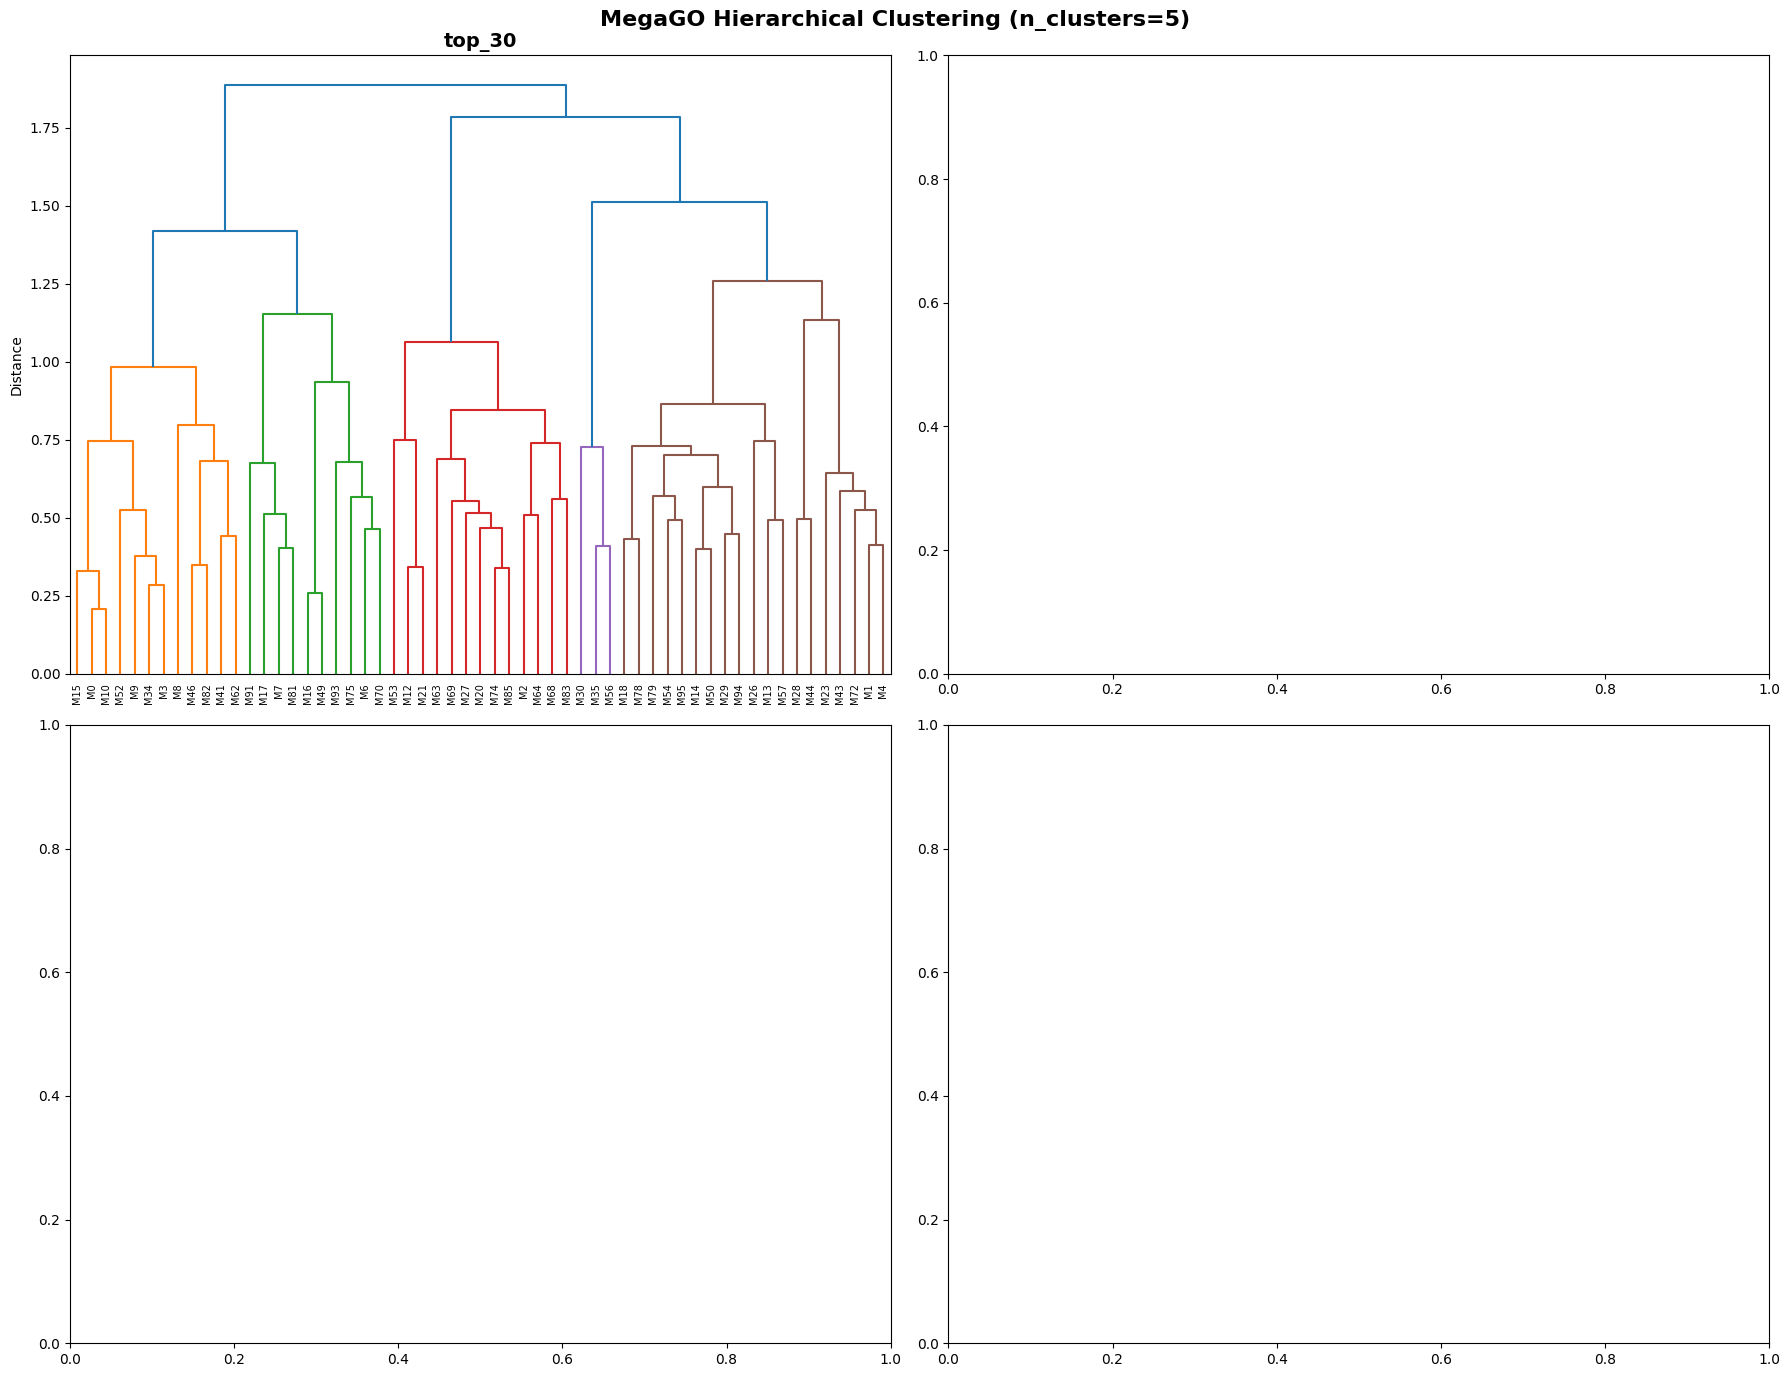


Dendrogram comparison saved.


In [13]:
# Cluster modules for each MegaGO configuration
cluster_assignments = {}  # {config_name: {module_id_str: cluster_label}}
linkage_results = {}

# Number of clusters - can be adjusted
n_clusters = 5

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, (config_name, sim_df) in enumerate(similarity_matrices.items()):
    print(f"\nClustering for: {config_name}")
    
    # Convert similarity to distance
    sim_matrix = sim_df.values
    # Clip to [0, 1] range and convert to distance
    sim_clipped = np.clip(sim_matrix, 0, 1)
    dist_matrix = 1 - sim_clipped
    np.fill_diagonal(dist_matrix, 0)
    
    # Make symmetric (take average of upper/lower triangle)
    dist_matrix = (dist_matrix + dist_matrix.T) / 2
    
    # Hierarchical clustering
    condensed_dist = squareform(dist_matrix, checks=False)
    Z = linkage(condensed_dist, method='ward')
    linkage_results[config_name] = Z
    
    # Cut tree to get cluster assignments
    clusters = fcluster(Z, t=n_clusters, criterion='maxclust')
    
    module_labels = sim_df.index.tolist()
    module_clusters = {}
    for label, cluster in zip(module_labels, clusters):
        module_num = label.replace('Module_', '')
        module_clusters[module_num] = f'Cluster_{cluster}'
    
    cluster_assignments[config_name] = module_clusters
    
    # Print cluster sizes
    from collections import Counter
    cluster_counts = Counter(module_clusters.values())
    for c, count in sorted(cluster_counts.items()):
        print(f"  {c}: {count} modules")
    
    # Plot dendrogram
    ax = axes[idx]
    short_labels = [l.replace('Module_', 'M') for l in module_labels]
    dendrogram(Z, labels=short_labels, ax=ax, leaf_rotation=90, leaf_font_size=7,
               color_threshold=Z[-(n_clusters-1), 2])
    ax.set_title(f'{config_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Distance')

plt.suptitle(f'MegaGO Hierarchical Clustering (n_clusters={n_clusters})', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'dendrograms_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nDendrogram comparison saved.")

Evaluating optimal cluster numbers for megaGO similarity matrices...

top_30:
  k= 2: Silhouette= 0.0900, Davies-Bouldin= 2.5097, Calinski-Harabasz=     7.8
  k= 3: Silhouette= 0.1067, Davies-Bouldin= 2.2035, Calinski-Harabasz=     7.7
  k= 4: Silhouette= 0.1245, Davies-Bouldin= 1.8133, Calinski-Harabasz=     7.7
  k= 5: Silhouette= 0.1197, Davies-Bouldin= 1.7746, Calinski-Harabasz=     7.6
  k= 6: Silhouette= 0.1214, Davies-Bouldin= 1.6797, Calinski-Harabasz=     7.5
  k= 7: Silhouette= 0.1255, Davies-Bouldin= 1.6447, Calinski-Harabasz=     7.3
  k= 8: Silhouette= 0.1394, Davies-Bouldin= 1.5413, Calinski-Harabasz=     6.9
  k= 9: Silhouette= 0.1429, Davies-Bouldin= 1.5907, Calinski-Harabasz=     6.4
  k=10: Silhouette= 0.1396, Davies-Bouldin= 1.5758, Calinski-Harabasz=     6.4
  k=11: Silhouette= 0.1508, Davies-Bouldin= 1.4988, Calinski-Harabasz=     6.2
  → Optimal k (Silhouette): 11
  → Optimal k (Davies-Bouldin): 11


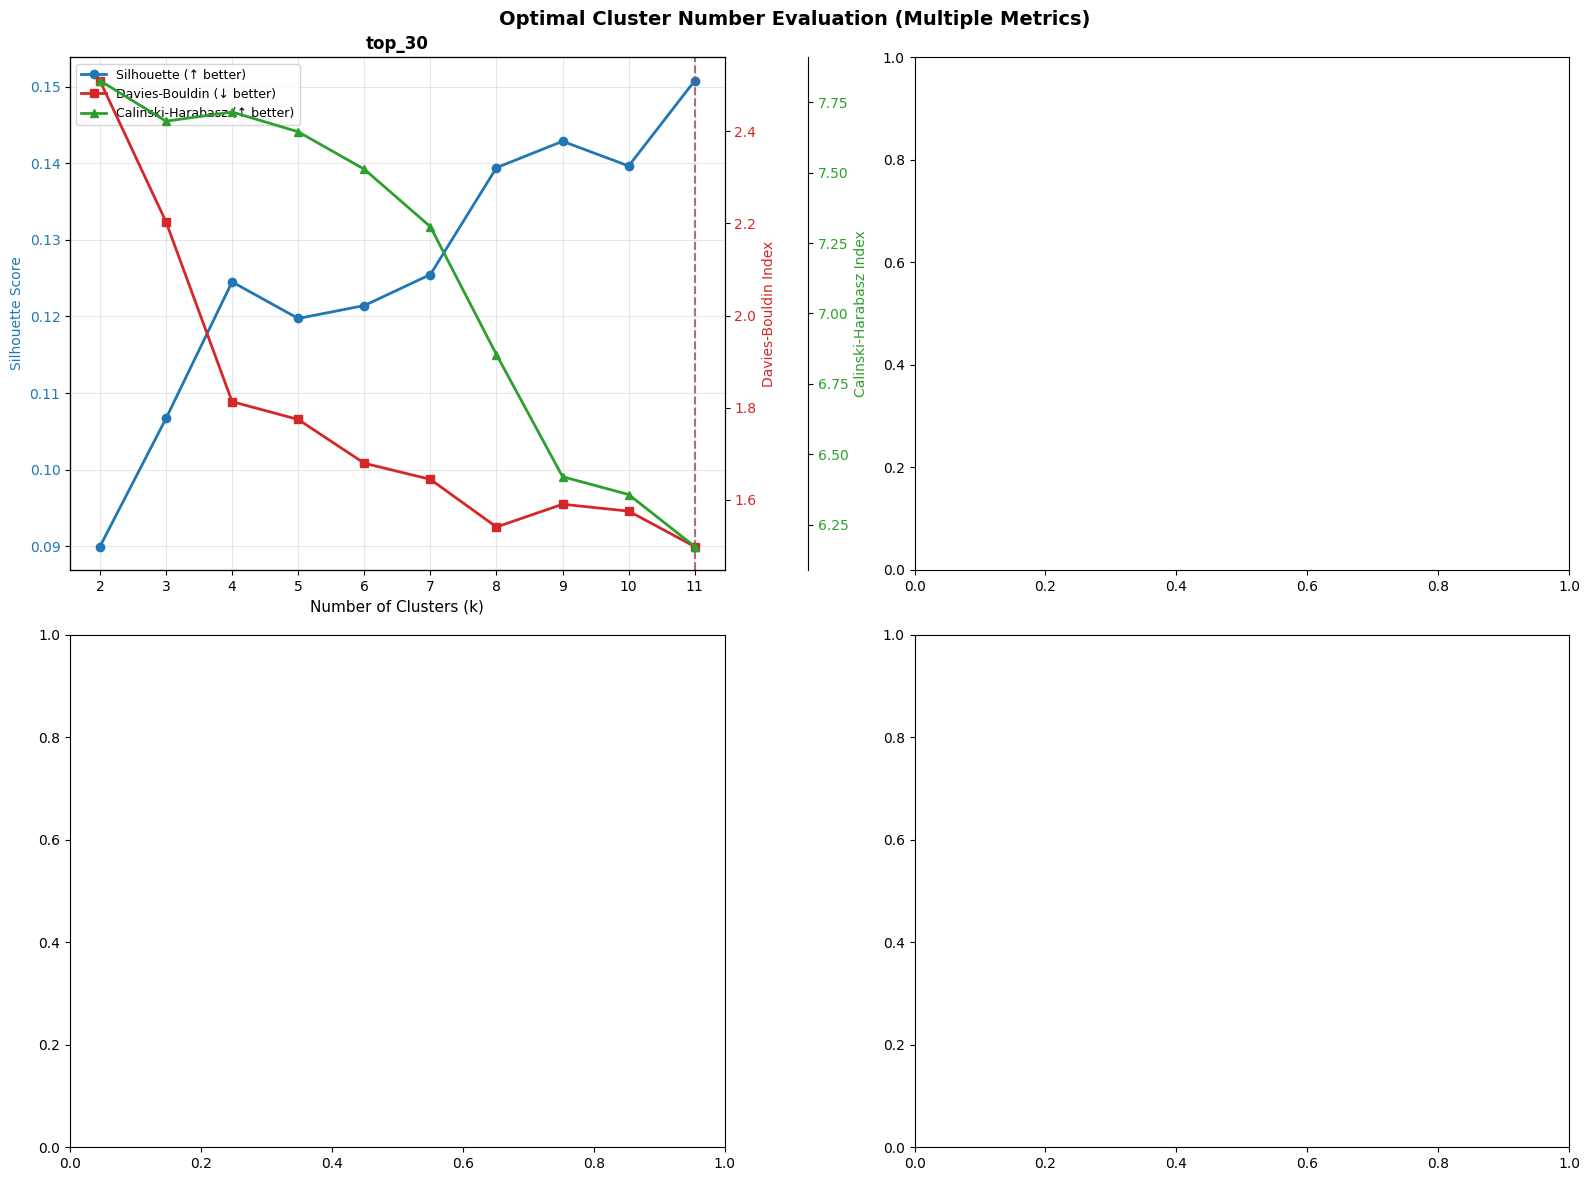


SUMMARY OF OPTIMAL CLUSTER COUNTS BY METHOD:

top_30:
  Silhouette:       k = 11
  Davies-Bouldin:   k = 11

Note: Different methods may suggest different optimal k.
Consider consensus or domain knowledge when choosing cluster count.


In [16]:
# Find optimal number of clusters using multiple metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

print("Evaluating optimal cluster numbers for megaGO similarity matrices...")
print("=" * 80)

optimal_clusters = {}  # store results for each config
cluster_range = range(2, 12)  # test 2 to 11 clusters

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (config_name, sim_df) in enumerate(similarity_matrices.items()):
    print(f"\n{config_name}:")
    
    # Convert similarity to distance
    sim_matrix = sim_df.values
    sim_clipped = np.clip(sim_matrix, 0, 1)
    dist_matrix = 1 - sim_clipped
    np.fill_diagonal(dist_matrix, 0)
    dist_matrix = (dist_matrix + dist_matrix.T) / 2
    
    # Perform hierarchical clustering once
    condensed_dist = squareform(dist_matrix, checks=False)
    Z = linkage(condensed_dist, method='ward')
    
    # Evaluate different cluster numbers
    silhouette_scores = []
    davies_bouldin_scores = []
    calinski_harabasz_scores = []
    distances = []  # for elbow method
    
    for k in cluster_range:
        clusters = fcluster(Z, t=k, criterion='maxclust')
        
        # Silhouette score (higher is better, range: -1 to 1)
        sil_score = silhouette_score(dist_matrix, clusters, metric='precomputed')
        silhouette_scores.append(sil_score)
        
        # Davies-Bouldin index (lower is better)
        db_score = davies_bouldin_score(sim_clipped, clusters)  # use similarity for this
        davies_bouldin_scores.append(db_score)
        
        # Calinski-Harabasz index (higher is better)
        ch_score = calinski_harabasz_score(sim_clipped, clusters)
        calinski_harabasz_scores.append(ch_score)
        
        # For elbow method: use last merge distance
        distances.append(Z[-(k-1), 2] if k > 1 else 0)
        
        print(f"  k={k:2d}: Silhouette={sil_score:7.4f}, Davies-Bouldin={db_score:7.4f}, Calinski-Harabasz={ch_score:8.1f}")
    
    # Find optimal k for each metric
    optimal_sil = list(cluster_range)[np.argmax(silhouette_scores)]
    optimal_db = list(cluster_range)[np.argmin(davies_bouldin_scores)]
    
    optimal_clusters[config_name] = {
        'silhouette': optimal_sil,
        'davies_bouldin': optimal_db,
        'all_scores': {
            'silhouette': silhouette_scores,
            'davies_bouldin': davies_bouldin_scores,
            'calinski_harabasz': calinski_harabasz_scores,
            'distances': distances
        }
    }
    
    print(f"  → Optimal k (Silhouette): {optimal_sil}")
    print(f"  → Optimal k (Davies-Bouldin): {optimal_db}")
    
    # Plot metrics
    ax = axes.flatten()[idx]
    ax2 = ax.twinx()
    ax3 = ax.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    
    p1, = ax.plot(cluster_range, silhouette_scores, 'o-', linewidth=2, markersize=6, 
                   color='tab:blue', label='Silhouette (↑ better)')
    p2, = ax2.plot(cluster_range, davies_bouldin_scores, 's-', linewidth=2, markersize=6,
                    color='tab:red', label='Davies-Bouldin (↓ better)')
    p3, = ax3.plot(cluster_range, calinski_harabasz_scores, '^-', linewidth=2, markersize=6,
                    color='tab:green', label='Calinski-Harabasz (↑ better)')
    
    ax.set_xlabel('Number of Clusters (k)', fontsize=11)
    ax.set_ylabel('Silhouette Score', color='tab:blue', fontsize=10)
    ax2.set_ylabel('Davies-Bouldin Index', color='tab:red', fontsize=10)
    ax3.set_ylabel('Calinski-Harabasz Index', color='tab:green', fontsize=10)
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax3.tick_params(axis='y', labelcolor='tab:green')
    ax.set_title(f'{config_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(cluster_range)
    
    # Highlight optimal values
    ax.axvline(optimal_sil, color='tab:blue', linestyle='--', alpha=0.5)
    ax2.axvline(optimal_db, color='tab:red', linestyle='--', alpha=0.5)
    
    # Add legend
    lines = [p1, p2, p3]
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='upper left', fontsize=9)

plt.suptitle('Optimal Cluster Number Evaluation (Multiple Metrics)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'optimal_clusters_metrics.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 80)
print("SUMMARY OF OPTIMAL CLUSTER COUNTS BY METHOD:")
for config_name, results in optimal_clusters.items():
    print(f"\n{config_name}:")
    print(f"  Silhouette:       k = {results['silhouette']}")
    print(f"  Davies-Bouldin:   k = {results['davies_bouldin']}")
print("\nNote: Different methods may suggest different optimal k.")
print("Consider consensus or domain knowledge when choosing cluster count.")


In [17]:
# Compare cluster stability across configurations
print("Cluster assignment comparison across MegaGO configurations:")
print("="*80)

# Build comparison table
all_modules = sorted(set().union(*[set(v.keys()) for v in cluster_assignments.values()]), key=int)
comparison_df = pd.DataFrame(index=all_modules)
for config_name, assignments in cluster_assignments.items():
    comparison_df[config_name] = comparison_df.index.map(lambda m: assignments.get(m, 'N/A'))

print(comparison_df.to_string())
comparison_df.to_csv(os.path.join(output_dir, 'cluster_assignments_comparison.csv'))
print(f"\nSaved to: {os.path.join(output_dir, 'cluster_assignments_comparison.csv')}")

Cluster assignment comparison across MegaGO configurations:
       top_30
0   Cluster_1
1   Cluster_5
2   Cluster_3
3   Cluster_1
4   Cluster_5
6   Cluster_2
7   Cluster_2
8   Cluster_1
9   Cluster_1
10  Cluster_1
12  Cluster_3
13  Cluster_5
14  Cluster_5
15  Cluster_1
16  Cluster_2
17  Cluster_2
18  Cluster_5
20  Cluster_3
21  Cluster_3
23  Cluster_5
26  Cluster_5
27  Cluster_3
28  Cluster_5
29  Cluster_5
30  Cluster_4
34  Cluster_1
35  Cluster_4
41  Cluster_1
43  Cluster_5
44  Cluster_5
46  Cluster_1
49  Cluster_2
50  Cluster_5
52  Cluster_1
53  Cluster_3
54  Cluster_5
56  Cluster_4
57  Cluster_5
62  Cluster_1
63  Cluster_3
64  Cluster_3
68  Cluster_3
69  Cluster_3
70  Cluster_2
72  Cluster_5
74  Cluster_3
75  Cluster_2
78  Cluster_5
79  Cluster_5
81  Cluster_2
82  Cluster_1
83  Cluster_3
85  Cluster_3
91  Cluster_2
93  Cluster_2
94  Cluster_5
95  Cluster_5

Saved to: ./Networks/megaGO_exploration/cluster_assignments_comparison.csv


In [18]:
# Generate or load rrvgo labels for the canonical top_30 MegaGO configuration
top30_output_dir = os.path.join(output_dir, 'top_30')
os.makedirs(top30_output_dir, exist_ok=True)

top30_cluster_assignments_file = os.path.join(top30_output_dir, 'cluster_assignments_top_30.csv')
comparison_df.to_csv(top30_cluster_assignments_file, index_label='Module')
print(f"Saved canonical top_30 assignments to: {top30_cluster_assignments_file}")

rrvgo_helper = '/home/borisvdm/repo/LemonIte/Lloyd-Price/Lemonite/rrvgo_cluster_labels.R'
rrvgo_cluster_labels_file = os.path.join(top30_output_dir, 'rrvgo_cluster_labels_top_30.csv')
rrvgo_module_labels_file = os.path.join(top30_output_dir, 'rrvgo_module_labels_top_30.csv')
rrvgo_reduced_terms_file = os.path.join(top30_output_dir, 'rrvgo_reduced_terms_top_30.csv')

rrvgo_cluster_labels = {}
rrvgo_module_labels = {}
rrvgo_module_representative_go_ids = {}
rrvgo_cluster_label_rows = pd.DataFrame()
rrvgo_module_label_rows = pd.DataFrame()
rrvgo_reduced_terms_rows = pd.DataFrame()

force_rrvgo_rebuild = False
rrvgo_outputs = [
    rrvgo_cluster_labels_file,
    rrvgo_module_labels_file,
    rrvgo_reduced_terms_file,
]

if force_rrvgo_rebuild or not all(os.path.exists(path) for path in rrvgo_outputs):
    rscript_exe = shutil.which('Rscript')
    if not rscript_exe:
        raise RuntimeError('Rscript is required to generate rrvgo labels.')

    cmd = [
        rscript_exe,
        rrvgo_helper,
        f"--enrichment={os.path.abspath(enrichment_all_file)}",
        f"--clusters={top30_cluster_assignments_file}",
        f"--out-dir={top30_output_dir}",
        '--cluster-column=top_30',
        '--top-n=30',
        '--ontology=BP',
        '--threshold=0.7',
        '--method=Rel',
        f'--cores={rrvgo_cores}',
    ]

    print('Running rrvgo helper...')
    completed = subprocess.run(cmd, capture_output=True, text=True, check=False)
    if completed.stdout.strip():
        print(completed.stdout.strip())
    if completed.stderr.strip():
        print(completed.stderr.strip())
    if completed.returncode != 0:
        raise RuntimeError('rrvgo label generation failed. See output above for details.')
else:
    print('Using cached rrvgo label outputs.')

rrvgo_cluster_label_rows = pd.read_csv(rrvgo_cluster_labels_file)
rrvgo_module_label_rows = pd.read_csv(rrvgo_module_labels_file)
rrvgo_reduced_terms_rows = pd.read_csv(rrvgo_reduced_terms_file)

rrvgo_cluster_labels = dict(
    zip(
        rrvgo_cluster_label_rows['MegaGO_cluster'],
        rrvgo_cluster_label_rows['MegaGO_label'].fillna('')
    )
)
rrvgo_module_labels = dict(
    zip(
        rrvgo_module_label_rows['Module'].astype(str),
        rrvgo_module_label_rows['MegaGO_label'].fillna('')
    )
)
rrvgo_module_representative_go_ids = dict(
    zip(
        rrvgo_module_label_rows['Module'].astype(str),
        rrvgo_module_label_rows['representative_go_id'].fillna('')
    )
)

print('\nrrvgo cluster labels:')
print(rrvgo_cluster_label_rows[['MegaGO_cluster', 'MegaGO_label', 'label_source']].to_string(index=False))

Saved canonical top_30 assignments to: ./Networks/megaGO_exploration/top_30/cluster_assignments_top_30.csv
Using cached rrvgo label outputs.

rrvgo cluster labels:
MegaGO_cluster                      MegaGO_label     label_source
     Cluster_1 B cell receptor signaling pathway rrvgo_parentTerm
     Cluster_2           response to cadmium ion rrvgo_parentTerm
     Cluster_3            phospholipid transport rrvgo_parentTerm
     Cluster_4                  synapse assembly rrvgo_parentTerm
     Cluster_5 extracellular matrix organization rrvgo_parentTerm


## Step 4: Network Data Preparation

In [15]:
# Network Data Preparation Function
def prepare_network_data():
    """Prepare nodes and edges for the interactive network visualization"""
    nodes = []
    edges = []
    regulator_modules = {'TF': {}, 'metabolite': {}}

    for _, row in module_overview.iterrows():
        module_id = str(row['Module'])
        hover_text = f"<b>Module {module_id}</b><br>"
        
        if 'Expression_p_value' in row and row['Expression_p_value'] != 'NA':
            hover_text += f"<b>Expression Analysis:</b><br>"
            hover_text += f"  \u2022 p-value: {row['Expression_p_value']:.2e}<br>"
            hover_text += f"  \u2022 Rank: {row['Expression_rank']}<br>"
            hover_text += f"  \u2022 Significant: {row['Expression_significant']}<br><br>"
        
        if row['Module_genes'] != 'NA' and pd.notna(row['Module_genes']):
            gene_count = len(row['Module_genes'].split('|'))
            hover_text += f"<b>Genes:</b> {gene_count} genes<br>"

        module_node = {'id': f"Module_{module_id}", 'label': f"M{module_id}", 'type': 'module', 'hover_info': hover_text}
        nodes.append(module_node)

        if 'TF_regulators' in row and pd.notna(row['TF_regulators']) and row['TF_regulators'] != 'NA':
            for tf in [t.strip() for t in str(row['TF_regulators']).split('|') if t.strip()]:
                regulator_modules['TF'].setdefault(tf, []).append(module_id)

        if 'Metabolite_regulators' in row and pd.notna(row['Metabolite_regulators']) and row['Metabolite_regulators'] != 'NA':
            for met in [m.strip() for m in str(row['Metabolite_regulators']).split('|') if m.strip()]:
                regulator_modules['metabolite'].setdefault(met, []).append(module_id)

    for reg_type, regulators in regulator_modules.items():
        for regulator, target_modules in regulators.items():
            reg_node = {
                'id': regulator, 'label': name_lookup.get(regulator, regulator), 'type': reg_type,
                'hover_info': f"<b>{reg_type.upper()}:</b> {name_lookup.get(regulator, regulator)}<br><b>Targets ({len(target_modules)}):</b> M{', M'.join(target_modules)}"
            }
            nodes.append(reg_node)
            for m in target_modules:
                edges.append({'source': regulator, 'target': f"Module_{m}", 'type': f"{reg_type}_to_module"})

    print(f"Network data prepared: {len(nodes)} nodes, {len(edges)} edges")
    return nodes, edges, regulator_modules

print("Network data preparation function defined!")

Network data preparation function defined!


In [19]:
# Regulator Filtering Function with Score-based Selection
def filter_top_regulators(nodes, edges, regulator_scores, min_targets=3, max_regulators_per_type=20,
                          min_score=None, top_pairs_by_score=5):
    """Filter regulators based on connectivity and also include top regulator-module pairs by score."""
    node_types = {n['id']: n['type'] for n in nodes}
    regulator_targets = {}
    regulator_avg_scores = {}
    all_scored_pairs = []
    
    for edge in edges:
        source = edge['source']
        if source in node_types and node_types[source] in ['TF', 'metabolite']:
            if source not in regulator_targets:
                regulator_targets[source] = []
            target_module = edge['target'].replace('Module_', '')
            regulator_targets[source].append(target_module)
            
            reg_type = node_types[source]
            score_dict = regulator_scores.get(reg_type, {})
            pair_score = score_dict.get((source, target_module), 0)
            all_scored_pairs.append({
                'regulator': source, 'module': target_module, 'target': edge['target'],
                'score': pair_score, 'type': reg_type
            })
            
            scores = [score_dict.get((source, mod), 0) for mod in regulator_targets[source]]
            regulator_avg_scores[source] = sum(scores) / len(scores) if scores else 0
    
    regulators_by_type = {'TF': [], 'metabolite': []}
    for reg_id, target_list in regulator_targets.items():
        count = len(target_list)
        avg_score = regulator_avg_scores.get(reg_id, 0)
        if count >= min_targets:
            if min_score is None or avg_score >= min_score:
                reg_type = node_types[reg_id]
                regulators_by_type[reg_type].append((reg_id, count, avg_score))
    
    selected_regulators = set()
    connectivity_edges = []
    
    for reg_type, regs in regulators_by_type.items():
        sorted_regs = sorted(regs, key=lambda x: (x[1], x[2]), reverse=True)
        if len(sorted_regs) <= max_regulators_per_type:
            selected_regulators.update([r[0] for r in sorted_regs])
        else:
            cutoff_count = sorted_regs[max_regulators_per_type - 1][1]
            top_regs = [r for r in sorted_regs if r[1] >= cutoff_count]
            selected_regulators.update([r[0] for r in top_regs[:max_regulators_per_type]])
    
    for edge in edges:
        if edge['source'] in selected_regulators or edge['source'].startswith('Module_'):
            connectivity_edges.append(edge)
    
    scored_pairs_by_type = {'TF': [], 'metabolite': []}
    for pair in all_scored_pairs:
        scored_pairs_by_type[pair['type']].append(pair)
    
    top_scoring_pairs = []
    for reg_type in ['TF', 'metabolite']:
        sorted_pairs = sorted(scored_pairs_by_type[reg_type], key=lambda x: x['score'], reverse=True)
        top_scoring_pairs.extend(sorted_pairs[:top_pairs_by_score])
    
    score_based_edges = []
    for pair in top_scoring_pairs:
        selected_regulators.add(pair['regulator'])
        edge_obj = {'source': pair['regulator'], 'target': pair['target'], 'type': f"{pair['type']}_to_module"}
        if edge_obj not in connectivity_edges and edge_obj not in score_based_edges:
            score_based_edges.append(edge_obj)
    
    all_filtered_edges = connectivity_edges + score_based_edges
    filtered_nodes = [n for n in nodes if n['type'] == 'module' or n['id'] in selected_regulators]
    
    regulators_by_type_with_scores = {}
    for reg_type, regs in regulators_by_type.items():
        regulators_by_type_with_scores[reg_type] = [(r[0], r[1], r[2]) for r in regs]
    
    return filtered_nodes, all_filtered_edges, regulators_by_type_with_scores, top_scoring_pairs

print("Regulator filtering function defined!")

Regulator filtering function defined!


In [20]:
# Load expression data and compute module eigengenes for regulator-module correlation
from scipy import stats
import numpy as np

expr_file = '/home/borisvdm/Documents/PhD/Lemonite/Lloyd-Price_IBD/results/LemonTree/Preprocessing/LemonPreprocessed_complete.txt'
expr_df = pd.read_csv(expr_file, sep='\t', index_col=0)
expr_df = expr_df.apply(pd.to_numeric, errors='coerce')
print(f"Expression data loaded: {expr_df.shape[0]} features x {expr_df.shape[1]} samples")

# Compute eigengenes for each module using SVD on member genes
module_eigengenes = {}
for mod_id, genes in module_genes_map.items():
    available_genes = [g for g in genes if g in expr_df.index]
    if len(available_genes) < 2:
        continue
    mod_expr = expr_df.loc[available_genes].values.astype(float)
    n_samples = mod_expr.shape[1]
    # Remove samples (columns) where any module gene has NaN
    # This is more appropriate for multi-omics data where rows may have sparse NaN
    valid_cols = ~np.any(np.isnan(mod_expr), axis=0)
    mod_expr_clean = mod_expr[:, valid_cols]
    if mod_expr_clean.shape[0] < 2 or mod_expr_clean.shape[1] < 3:
        continue
    # Center the data (per-gene mean across samples) and compute first right singular vector (eigengene)
    mod_expr_centered = mod_expr_clean - mod_expr_clean.mean(axis=1, keepdims=True)
    try:
        U, S, Vt = np.linalg.svd(mod_expr_centered, full_matrices=False)
        ev = Vt[0]  # first right singular vector = eigengene, shape (n_samples,)
        # SVD sign is arbitrary: align so eigengene is positively correlated with
        # the average expression of module genes (WGCNA convention).
        mean_corr = np.mean([np.corrcoef(ev, gene_row)[0, 1]
            for gene_row in mod_expr_centered])
        if mean_corr < 0:
            ev = -ev  # flip so the eigengene aligns with the majority of genes
        # Store as full-length vector with NaN for dropped samples
        ev_full = np.full(n_samples, np.nan)
        ev_full[valid_cols] = ev
        module_eigengenes[mod_id] = ev_full
    except np.linalg.LinAlgError:
        continue
print(f"Computed eigengenes for {len(module_eigengenes)}/{len(module_genes_map)} modules")

# Function to compute Pearson correlation between regulator expression and module eigengene
def compute_reg_module_correlation(regulator, module_id):
    """Compute Pearson correlation between a regulator's expression and a module's eigengene."""
    if module_id not in module_eigengenes:
        return 0.0
    if regulator not in expr_df.index:
        return 0.0
    reg_data = expr_df.loc[regulator]
    # Handle duplicate index entries: take the first match
    if isinstance(reg_data, pd.DataFrame):
        reg_data = reg_data.iloc[0]
    reg_expr = reg_data.values.astype(float)
    eigengene = module_eigengenes[module_id]
    valid = ~(np.isnan(reg_expr) | np.isnan(eigengene))
    if valid.sum() < 3:
        return 0.0
    corr, _ = stats.pearsonr(reg_expr[valid], eigengene[valid])
    return corr

def annotate_edges_with_correlation(edges):
    """Add Pearson correlation values to each edge (regulator vs module eigengene)."""
    n_computed = 0
    for edge in edges:
        reg = edge['source']
        mod = edge['target'].replace('Module_', '')
        corr = compute_reg_module_correlation(reg, mod)
        edge['correlation'] = round(corr, 4)
        if corr != 0.0:
            n_computed += 1
    pos = sum(1 for e in edges if e.get('correlation', 0) > 0)
    neg = sum(1 for e in edges if e.get('correlation', 0) < 0)
    zero = sum(1 for e in edges if e.get('correlation', 0) == 0)
    print(f"Correlation annotated: {n_computed}/{len(edges)} edges with non-zero correlation")
    print(f"  Positive: {pos}, Negative: {neg}, Zero/NA: {zero}")
    return edges

print("Correlation computation functions defined.")


Expression data loaded: 5762 features x 76 samples
Computed eigengenes for 86/86 modules
Correlation computation functions defined.


In [21]:
# Prepare network data and filter regulators (shared across all configs)
print("Preparing network data...")
nodes, edges, regulator_modules = prepare_network_data()

# annotate edges with interaction category based on PKN
edges = annotate_edges_with_category(edges)
from collections import Counter
print("Edge categories distribution:", Counter([e.get('category','Other') for e in edges]))

# annotate edges with regulator-module correlation
edges = annotate_edges_with_correlation(edges)

# keep a copy of the unfiltered network so we can also generate a full view
full_nodes, full_edges = nodes, edges

print("\nFiltering regulators...")
filtered_nodes, filtered_edges, regulator_stats, top_pairs = filter_top_regulators(
    nodes, edges, regulator_scores,
    min_targets=3, max_regulators_per_type=10,
    min_score=None, top_pairs_by_score=5
)
print(f"Filtered: {len(filtered_nodes)} nodes, {len(filtered_edges)} edges")

# dictionary of network variants we will use later
network_variants = {
    'filtered': (filtered_nodes, filtered_edges),
    'full': (full_nodes, full_edges)
}


Preparing network data...
Network data prepared: 522 nodes, 908 edges
Edge categories distribution: Counter({'Other': 870, 'Metabolic_pathway': 37, 'Causal': 1})
Correlation annotated: 581/908 edges with non-zero correlation
  Positive: 422, Negative: 159, Zero/NA: 327

Filtering regulators...
Filtered: 113 nodes, 192 edges


## Step 5: visualization in python html network

This section will create **two versions** of the module‑regulator network for each MegaGO configuration:
- a **filtered** network that retains only top regulators (as before)
- a **full** network with no selection, i.e. every node and edge generated from the data

Both variants are written out with distinct filenames and exported to Cytoscape later.

In [22]:
# helper to spread overlapping module nodes
def adjust_positions_to_avoid_overlap(pos, min_dist=60):
    '''Ensure every pair of module nodes are at least min_dist apart.'''
    moved=True
    import numpy as np, random
    while moved:
        moved=False
        items=list(pos.items())
        for i,(n1,(x1,y1)) in enumerate(items):
            if not n1.startswith('Module_'): continue
            for n2,(x2,y2) in items[i+1:]:
                if not n2.startswith('Module_'): continue
                dx=x2-x1; dy=y2-y1
                dist=np.hypot(dx,dy)
                if dist==0:
                    dx=random.uniform(-1,1); dy=random.uniform(-1,1)
                    dist=np.hypot(dx,dy)
                if dist<min_dist:
                    shift=(min_dist-dist)/2.0
                    angle=np.arctan2(dy,dx)
                    pos[n1]=(x1-shift*np.cos(angle), y1-shift*np.sin(angle))
                    pos[n2]=(x2+shift*np.cos(angle), y2+shift*np.sin(angle))
                    moved=True
    return pos


In [23]:
# ensure overlap helper available when networks are built
def adjust_positions_to_avoid_overlap(pos, min_dist=60):
    '''Pull overlapping module nodes apart.'''
    moved=True
    import numpy as np, random
    while moved:
        moved=False
        items=list(pos.items())
        for j,(n1,(x1,y1)) in enumerate(items):
            if not n1.startswith('Module_'): continue
            for n2,(x2,y2) in items[j+1:]:
                if not n2.startswith('Module_'): continue
                dx=x2-x1; dy=y2-y1
                dist=np.hypot(dx,dy)
                if dist==0:
                    dx=random.uniform(-1,1); dy=random.uniform(-1,1)
                    dist=np.hypot(dx,dy)
                if dist<min_dist:
                    shift=(min_dist-dist)/2.0
                    ang=np.arctan2(dy,dx)
                    pos[n1]=(x1-shift*np.cos(ang), y1-shift*np.sin(ang))
                    pos[n2]=(x2+shift*np.cos(ang), y2+shift*np.sin(ang))
                    moved=True
    return pos

# helper overlapping modules
def adjust_positions_to_avoid_overlap(pos, min_dist=60):
    '''push module nodes apart until min_dist apart.'''
    moved=True
    import numpy as np, random
    while moved:
        moved=False
        items=list(pos.items())
        for j,(n1,(x1,y1)) in enumerate(items):
            if not n1.startswith('Module_'): continue
            for n2,(x2,y2) in items[j+1:]:
                if not n2.startswith('Module_'): continue
                dx=x2-x1; dy=y2-y1
                dist=np.hypot(dx,dy)
                if dist==0:
                    dx=random.uniform(-1,1); dy=random.uniform(-1,1)
                    dist=np.hypot(dx,dy)
                if dist<min_dist:
                    shift=(min_dist-dist)/2.0
                    ang=np.arctan2(dy,dx)
                    pos[n1]=(x1-shift*np.cos(ang), y1-shift*np.sin(ang))
                    pos[n2]=(x2+shift*np.cos(ang), y2+shift*np.sin(ang))
                    moved=True
    return pos

# Interactive HTML Network Visualization (Plotly) - colored by MegaGO cluster
import plotly.graph_objects as go


def create_megago_cluster_layout(nodes, edges, module_clusters):
    """Create layout where modules are positioned based on their MegaGO cluster."""
    clusters = list(set(module_clusters.values()))
    n_clusters_layout = len(clusters)
    
    cluster_positions = {}
    for i, cl in enumerate(clusters):
        angle = 2 * np.pi * i / n_clusters_layout
        radius = 8
        cluster_positions[cl] = (radius * np.cos(angle), radius * np.sin(angle))
    
    pos = {}
    modules_by_cluster = {cl: [] for cl in clusters}
    for node in nodes:
        if node['type'] == 'module':
            module_id = node['id'].replace('Module_', '')
            cl = module_clusters.get(module_id, 'Unassigned')
            if cl not in modules_by_cluster:
                modules_by_cluster[cl] = []
            modules_by_cluster[cl].append(node['id'])
    
    np.random.seed(42)
    for cl, module_ids in modules_by_cluster.items():
        if cl not in cluster_positions:
            cluster_positions[cl] = (0, 0)
        center_x, center_y = cluster_positions[cl]
        n_modules = len(module_ids)
        
        if n_modules == 1:
            pos[module_ids[0]] = (center_x, center_y)
        else:
            for i, mod_id in enumerate(module_ids):
                angle = 2 * np.pi * i / n_modules
                jitter_radius = min(2.5, 0.5 + 0.3 * n_modules)
                x = center_x + jitter_radius * np.cos(angle)
                y = center_y + jitter_radius * np.sin(angle)
                pos[mod_id] = (x, y)
    
    # Position regulator nodes near their targets
    for node in nodes:
        if node['id'] not in pos:
            connected_modules = [e['target'] for e in edges if e['source'] == node['id']]
            if connected_modules:
                # determine cluster membership of targets
                connected_clusters = set(
                    module_clusters.get(m.replace('Module_', ''), 'Unassigned')
                    for m in connected_modules
                )
                connected_pos = [pos[m] for m in connected_modules if m in pos]
                if connected_pos:
                    if len(connected_clusters) == 1:
                        # if all targets in single cluster, start at cluster center
                        center_x, center_y = cluster_positions[next(iter(connected_clusters))]
                    else:
                        # otherwise average the module positions
                        center_x = np.mean([p[0] for p in connected_pos])
                        center_y = np.mean([p[1] for p in connected_pos])
                    offset_dist = 1.5
                    if node['type'] == 'TF':
                        angle_offset = 0
                    elif node['type'] == 'metabolite':
                        angle_offset = 2 * np.pi / 3
                    else:
                        angle_offset = 4 * np.pi / 3
                    offset_x = offset_dist * np.cos(angle_offset + np.random.normal(0, 0.5))
                    offset_y = offset_dist * np.sin(angle_offset + np.random.normal(0, 0.5))
                    pos[node['id']] = (center_x + offset_x, center_y + offset_y)
                else:
                    pos[node['id']] = (0, 0)
            else:
                pos[node['id']] = (0, 0)
    
    return pos, cluster_positions


def build_enriched_hover_text(module_id, module_overview, module_enrichment_all, edges):
    """Build rich hover text for a module node including expression, regulators, and enrichment info."""
    hover_text = f"<b>Module {module_id}</b><br>"
    row = module_overview[module_overview['Module'].astype(str) == str(module_id)]
    if len(row) > 0:
        row = row.iloc[0]
        # Expression analysis
        if 'Expression_p_value' in row.index and row['Expression_p_value'] != 'NA':
            try:
                hover_text += f"<b>Expression Analysis:</b><br>"
                hover_text += f"  \u2022 p-value: {float(row['Expression_p_value']):.2e}<br>"
                hover_text += f"  \u2022 Rank: {row['Expression_rank']}<br>"
                hover_text += f"  \u2022 Significant: {row['Expression_significant']}<br><br>"
            except (ValueError, TypeError):
                pass
        # Gene count
        if 'Module_genes' in row.index and row['Module_genes'] != 'NA' and pd.notna(row['Module_genes']):
            gene_count = len(str(row['Module_genes']).split('|'))
            hover_text += f"<b>Genes:</b> {gene_count} genes<br><br>"
    # Regulators per type
    module_target = f"Module_{module_id}"
    reg_type_labels = {'TF': 'Transcription Factors', 'metabolite': 'Metabolites'}
    for reg_type, reg_label in reg_type_labels.items():
        regs = sorted(set(e['source'] for e in edges if e['target'] == module_target and e['type'] == f"{reg_type}_to_module"))
        if regs:
            hover_text += f"<b>{reg_label} ({len(regs)}):</b> "
            hover_text += ', '.join(name_lookup.get(r, r) for r in regs[:10])
            if len(regs) > 10:
                hover_text += f", ... (+{len(regs)-10} more)"
            hover_text += '<br>'
    hover_text += '<br>'
    # Top enriched pathways from ALL databases (BP, MF, CC, KEGG, Reactome)
    if module_enrichment_all is not None and not module_enrichment_all.empty:
        mod_enrich = module_enrichment_all[module_enrichment_all['Module'].astype(str) == str(module_id)]
        for db in ['BP', 'MF', 'CC', 'KEGG', 'Reactome']:
            db_enrich = mod_enrich[mod_enrich['Database'] == db].sort_values('p.adjust').head(3)
            if len(db_enrich) > 0:
                hover_text += f"<b>Top {db}:</b><br>"
                for _, erow in db_enrich.iterrows():
                    term = str(erow['Term'])
                    if len(term) > 55:
                        term = term[:52] + '...'
                    p_val = erow['p.adjust']
                    hover_text += f"  \u2022 {term} (p={p_val:.1e})<br>"
    return hover_text


def create_megago_interactive_network(nodes, edges, module_clusters, config_name,
                                      module_overview, module_enrichment_all, movable=False):
    """Create interactive Plotly network with modules colored by MegaGO cluster.

    If ``movable`` is True each node is placed in its own scatter trace so the
    resulting HTML (with ``config={'editable': True}``) lets you click‑and‑drag
    individual points to avoid overlaps.
    """
    # build enriched hover info & optionally split into per-node traces later
    enriched_nodes = []
    for node in nodes:
        enriched_node = dict(node)
        if node['type'] == 'module':
            module_id = node['id'].replace('Module_', '')
            enriched_node['hover_info'] = build_enriched_hover_text(
                module_id, module_overview, module_enrichment_all, edges
            )
            # Add cluster info to hover
            cluster = module_clusters.get(module_id, 'Unassigned')
            enriched_node['hover_info'] += f"<br><b>MegaGO Cluster:</b> {cluster}"
        enriched_nodes.append(enriched_node)
    # create layout positions
    pos, cluster_positions = create_megago_cluster_layout(enriched_nodes, edges, module_clusters)

    # color palette
    all_clusters = sorted(set(module_clusters.values()))
    cluster_palette = ['#EE6677', '#4477AA', '#228833', '#AA3377', '#66CCEE',
                       '#CCBB44', '#EE99AA', '#44BB99', '#BBCC33', '#AAAA00']
    cluster_color_map = {cl: cluster_palette[i % len(cluster_palette)] for i, cl in enumerate(all_clusters)}
    cluster_color_map['Unassigned'] = '#BBBBBB'
    regulator_color = '#FF8C00'

    # prepare edge traces by interaction category (Causal, Metabolic_pathway, Other)
    edge_styles = {
        'Causal': {'color': 'rgba(80,80,80,0.9)', 'width': 3.0, 'label': 'Causal'},
        'Metabolic_pathway': {'color': 'rgba(80,80,80,0.85)', 'width': 2.5, 'label': 'Metabolic pathway'},
        'Other': {'color': 'rgba(80,80,80,0.6)', 'width': 1.5, 'label': 'Other'}
    }
    edge_traces = {}
    for cat, style in edge_styles.items():
        edge_traces[cat] = go.Scatter(x=[], y=[],
                                      line=dict(width=style['width'], color=style['color']),
                                      hoverinfo='none', mode='lines',
                                      name=style['label'], showlegend=True)

    # accumulate coordinates into appropriate category traces
    # use temporary dicts because Scatter.x/y always return tuples
    temp_coords = {cat: {'x': [], 'y': []} for cat in edge_traces}
    for edge in edges:
        if edge['source'] in pos and edge['target'] in pos:
            x0, y0 = pos[edge['source']]
            x1, y1 = pos[edge['target']]
            cat = edge.get('category', 'Other')
            if cat not in temp_coords:
                cat = 'Other'
            temp_coords[cat]['x'].extend([x0, x1, None])
            temp_coords[cat]['y'].extend([y0, y1, None])

    # assign the accumulated lists back to the traces
    for cat, coords in temp_coords.items():
        edge_traces[cat].x = coords['x']
        edge_traces[cat].y = coords['y']

    # build figure with edge traces (draw Other first so thicker edges overlay)
    fig = go.Figure()
    for cat in ['Other', 'Metabolic_pathway', 'Causal']:
        fig.add_trace(edge_traces[cat])

    # ------------------------------------------------------------------
    # decorate the end of some edges
    # ------------------------------------------------------------------
    for edge in edges:
        if edge['source'] in pos and edge['target'] in pos:
            x0, y0 = pos[edge['source']]
            x1, y1 = pos[edge['target']]
            cat = edge.get('category', 'Other')
            if cat == 'Causal':
                # arrowhead pointing at the target
                fig.add_annotation(
                    x=x1, y=y1, ax=x0, ay=y0,
                    xref='x', yref='y', axref='x', ayref='y',
                    showarrow=True, arrowhead=3, arrowsize=1,
                    arrowwidth=edge_styles[cat]['width'],
                    arrowcolor=edge_styles[cat]['color'],
                    opacity=0.8
                )
            elif cat == 'Metabolic_pathway':
                # tiny dot at the target end
                fig.add_trace(go.Scatter(
                    x=[x1], y=[y1], mode='markers',
                    marker=dict(symbol='circle', size=6,
                                color=edge_styles[cat]['color'], line=dict(width=0)),
                    hoverinfo='none', showlegend=False
                ))

    if movable:
        # one trace per node to allow individual dragging
        for n in enriched_nodes:
            x = pos.get(n['id'], (0,0))[0]
            y = pos.get(n['id'], (0,0))[1]
            label = n.get('label', n['id'])
            txt = label if n['type']=='module' else label[:15]
            symbol = 'circle' if n['type']=='module' else 'diamond-wide'
            color = cluster_color_map.get(module_clusters.get(n['id'].replace('Module_',''), ''), '#BBBBBB') if n['type']=='module' else regulator_color
            size = 50 if n['type']=='module' else min(80, max(25, len(txt)*4))
            fig.add_trace(go.Scatter(x=[x], y=[y], mode='markers+text',
                                     marker=dict(size=size, color=color,
                                                 line=dict(width=2 if n['type']=='module' else 1, color='white' if n['type']=='module' else 'darkorange'),
                                                 symbol=symbol),
                                     text=[txt], textposition='middle center',
                                     textfont=dict(size=12 if n['type']=='module' else 8, color='black', family='Arial Black'),
                                     hovertext=[n.get('hover_info', txt)], hoverinfo='text',
                                     name=n['id'], showlegend=False))
    else:
        # grouped module traces by cluster
        module_traces = []
        for cluster in all_clusters:
            cat_nodes = [n for n in enriched_nodes if n['type']=='module' and
                         module_clusters.get(n['id'].replace('Module_',''),'Unassigned')==cluster]
            if not cat_nodes:
                continue
            x_vals = [pos[n['id']][0] for n in cat_nodes]
            y_vals = [pos[n['id']][1] for n in cat_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in cat_nodes]
            labels = [n['id'].replace('Module_','') for n in cat_nodes]
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=50, color=cluster_color_map.get(cluster,'#CCCCCC'),
                                          line=dict(width=2, color='white'), symbol='circle'),
                              text=labels, textposition='middle center',
                              textfont=dict(size=12, color='black', family='Arial Black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f"{cluster} ({len(cat_nodes)})", legendgroup=cluster)
            module_traces.append(trace)
        for tr in module_traces:
            fig.add_trace(tr)
        # unassigned
        unassigned_nodes = [n for n in enriched_nodes if n['type']=='module' and
                            module_clusters.get(n['id'].replace('Module_',''),'Unassigned')=='Unassigned']
        if unassigned_nodes:
            x_vals = [pos[n['id']][0] for n in unassigned_nodes]
            y_vals = [pos[n['id']][1] for n in unassigned_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in unassigned_nodes]
            labels = [n['id'].replace('Module_','') for n in unassigned_nodes]
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=50, color='#BBBBBB',
                                          line=dict(width=2, color='white'), symbol='circle'),
                              text=labels, textposition='middle center',
                              textfont=dict(size=12, color='black', family='Arial Black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f'Unassigned ({len(unassigned_nodes)})', legendgroup='Unassigned')
            fig.add_trace(trace)
        # regulator traces grouped by type
        regulator_traces = []
        for reg_type in ['TF','metabolite']:
            reg_nodes = [n for n in enriched_nodes if n['type']==reg_type]
            if not reg_nodes:
                continue
            x_vals = [pos[n['id']][0] for n in reg_nodes]
            y_vals = [pos[n['id']][1] for n in reg_nodes]
            hover_texts = [n.get('hover_info', n['label']) for n in reg_nodes]
            labels = [n['label'][:15] if len(n['label'])>15 else n['label'] for n in reg_nodes]
            sizes = [min(80, max(25, len(label)*4)) for label in labels]
            trace = go.Scatter(x=x_vals, y=y_vals, mode='markers+text',
                              marker=dict(size=sizes, color=regulator_color, symbol='diamond-wide',
                                          line=dict(width=1, color='darkorange')),
                              text=labels, textposition='middle center',
                              textfont=dict(size=8, color='black'),
                              hovertext=hover_texts, hoverinfo='text',
                              name=f"{reg_type.capitalize()} ({len(reg_nodes)})", legendgroup=f'reg_{reg_type}')
            regulator_traces.append(trace)
        for tr in regulator_traces:
            fig.add_trace(tr)
    # annotations for clusters
    annotations = []
    for cl, (x, y) in cluster_positions.items():
        annotations.append(dict(x=x*1.3, y=y*1.3, text=f'<b>{cl}</b>', showarrow=False,
                               font=dict(size=14, color=cluster_color_map.get(cl,'#000000')),
                               bgcolor='rgba(255,255,255,0.8)', borderpad=4))
    fig.update_layout(
        title=dict(text=f'Module-Regulator Network<br><sub>Modules colored by MegaGO cluster ({config_name})</sub>',
                   x=0.5, font=dict(size=20)),
        showlegend=True, hovermode='closest', width=1400, height=1000,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        plot_bgcolor='white', annotations=annotations,
        legend=dict(x=1.02, y=1, bgcolor='rgba(255,255,255,0.9)',
                    bordercolor='black', borderwidth=1, font=dict(size=10))
    )
    # for editable figures we don't need a special dragmode – configuration
    # passed to write_html (editable=True) already allows dragging individual
    # points.  Setting an unsupported value caused a ValueError earlier.
    return fig

# Generate interactive HTML networks for each MegaGO configuration
print("=" * 60)
print("INTERACTIVE HTML NETWORK VISUALIZATION (MegaGO clusters)")
print("=" * 60)

# iterate over variants (filtered vs full) so we can produce both versions
for variant_name, (nodes_to_use, edges_to_use) in network_variants.items():
    for config_name, module_clusters in cluster_assignments.items():
        print(f"Generating {variant_name} network for: {config_name}")
        config_subdir = os.path.join(output_dir, config_name, variant_name)
        os.makedirs(config_subdir, exist_ok=True)
        fig = create_megago_interactive_network(
            nodes_to_use, edges_to_use, module_clusters, config_name,
            module_overview, module_enrichment_all
        )
        html_path = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}.html')
        fig.write_html(html_path)
        print(f"  Saved: {html_path}")
        try:
            png_path = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}.png')
            fig.write_image(png_path, width=1400, height=1000, scale=2)
            print(f"  Saved: {png_path}")
        except Exception as e:
            print(f"  Note: Could not export PNG: {e}")
        fig.show()

        mov_fig = create_megago_interactive_network(
            nodes_to_use, edges_to_use, module_clusters, config_name,
            module_overview, module_enrichment_all, movable=True
        )
        mov_html = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}_movable.html')
        mov_fig.write_html(mov_html, config={'editable': True})
        print(f"  Saved movable version: {mov_html}")


print(f"All interactive HTML networks saved to: {output_dir}")

INTERACTIVE HTML NETWORK VISUALIZATION (MegaGO clusters)
Generating filtered network for: top_30
  Saved: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30.html
  Saved: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30.png


  Saved movable version: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30_movable.html
Generating full network for: top_30
  Saved: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30.html
  Saved: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30.png


  Saved movable version: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30_movable.html
All interactive HTML networks saved to: ./Networks/megaGO_exploration


In [24]:
# Patch the Plotly networks to surface rrvgo labels and regenerate the canonical HTML outputs
_original_build_enriched_hover_text = build_enriched_hover_text

def build_enriched_hover_text(module_id, module_overview, module_enrichment_all, edges):
    hover_text = _original_build_enriched_hover_text(
        module_id, module_overview, module_enrichment_all, edges
    )
    module_key = str(module_id)
    label = rrvgo_module_labels.get(module_key, '')
    representative_go_id = rrvgo_module_representative_go_ids.get(module_key, '')
    if label:
        hover_text += f"<b>Cluster Label:</b> {label}<br>"
        if representative_go_id:
            hover_text += f"<b>Representative GO:</b> {representative_go_id}<br>"
    return hover_text

_original_create_megago_interactive_network = create_megago_interactive_network

def _cluster_annotation_text(cluster_name):
    label = rrvgo_cluster_labels.get(cluster_name, '')
    if label:
        return f"<b>{cluster_name}</b><br><span style='font-size:11px'>{label}</span>"
    return f"<b>{cluster_name}</b>"

def _cluster_trace_name(trace_name):
    if not trace_name:
        return trace_name
    cluster_name = trace_name.split(' (')[0]
    label = rrvgo_cluster_labels.get(cluster_name, '')
    if not label:
        return trace_name
    suffix = trace_name[len(cluster_name):]
    return f"{cluster_name}: {label}{suffix}"

def create_megago_interactive_network(nodes, edges, module_clusters, config_name,
                                      module_overview, module_enrichment_all, movable=False):
    fig = _original_create_megago_interactive_network(
        nodes, edges, module_clusters, config_name,
        module_overview, module_enrichment_all, movable=movable
    )

    for annotation in fig.layout.annotations or []:
        cluster_name = re.sub(r'<[^>]+>', '', str(annotation.text)).strip()
        if cluster_name:
            annotation.text = _cluster_annotation_text(cluster_name)

    for trace in fig.data:
        legendgroup = getattr(trace, 'legendgroup', None)
        if legendgroup in rrvgo_cluster_labels:
            trace.name = _cluster_trace_name(trace.name)
            continue

        trace_name = getattr(trace, 'name', '')
        cluster_name = trace_name.split(' (')[0] if trace_name else ''
        if cluster_name in rrvgo_cluster_labels:
            trace.name = _cluster_trace_name(trace.name)

    return fig

print('=' * 60)
print('INTERACTIVE HTML NETWORK VISUALIZATION (MegaGO clusters + rrvgo labels)')
print('=' * 60)

for variant_name, (nodes_to_use, edges_to_use) in network_variants.items():
    for config_name, module_clusters in cluster_assignments.items():
        print(f"Generating {variant_name} network for: {config_name} (with rrvgo labels)")
        config_subdir = os.path.join(output_dir, config_name, variant_name)
        os.makedirs(config_subdir, exist_ok=True)

        fig = create_megago_interactive_network(
            nodes_to_use, edges_to_use, module_clusters, config_name,
            module_overview, module_enrichment_all
        )
        html_path = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}.html')
        fig.write_html(html_path)
        print(f"  Saved: {html_path}")

        try:
            png_path = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}.png')
            fig.write_image(png_path, width=1400, height=1000, scale=2)
            print(f"  Saved: {png_path}")
        except Exception as e:
            print(f"  Note: Could not export PNG: {e}")

        mov_fig = create_megago_interactive_network(
            nodes_to_use, edges_to_use, module_clusters, config_name,
            module_overview, module_enrichment_all, movable=True
        )
        mov_html = os.path.join(config_subdir, f'module_network_{variant_name}_megaGO_{config_name}_movable.html')
        mov_fig.write_html(mov_html, config={'editable': True})
        print(f"  Saved movable version: {mov_html}")

print(f"All interactive HTML networks saved to: {output_dir}")

INTERACTIVE HTML NETWORK VISUALIZATION (MegaGO clusters + rrvgo labels)
Generating filtered network for: top_30 (with rrvgo labels)
  Saved: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30.html
  Saved: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30.png
  Saved movable version: ./Networks/megaGO_exploration/top_30/filtered/module_network_filtered_megaGO_top_30_movable.html
Generating full network for: top_30 (with rrvgo labels)
  Saved: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30.html
  Saved: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30.png
  Saved movable version: ./Networks/megaGO_exploration/top_30/full/module_network_full_megaGO_top_30_movable.html
All interactive HTML networks saved to: ./Networks/megaGO_exploration


## Step 6: Cytoscape Visualization for Each MegaGO Configuration

Create a Cytoscape network for each configuration, with modules colored by MegaGO cluster.

In [25]:
# Export Cytoscape-compatible files for each configuration and variant
for config_name, module_clusters in cluster_assignments.items():
    for variant_name, (nodes_to_use, edges_to_use) in network_variants.items():
        print(f"\nExporting Cytoscape files for: {config_name} ({variant_name})")
        
        config_output = os.path.join(output_dir, config_name, variant_name)
        os.makedirs(config_output, exist_ok=True)
        
        cytoscape_sif = os.path.join(config_output, 'module_network_edges.txt')
        cytoscape_node_attr = os.path.join(config_output, 'module_network_node_attributes.txt')
        
        # combined edge list + attributes
        with open(cytoscape_sif, 'w') as f:
            f.write("source\ttarget\tCategory\tArrowShape\n")
            for edge in edges_to_use:
                cat = edge.get('category', 'Other')
                if cat == 'Causal':
                    arrow = 'DELTA'
                elif cat == 'Metabolic_pathway':
                    arrow = 'CIRCLE'
                else:
                    arrow = ''
                f.write(f"{edge['source']}\t{edge['target']}\t{cat}\t{arrow}\n")
        
        # node attributes (add expression/PPI/gene-count for modules)
        with open(cytoscape_node_attr, 'w') as f:
            f.write(
                "Node\tMegaGO_Cluster\tMegaGO_Label\tRepresentative_GO_ID\t"
                "Node_Type\tExpression_significant\tPPI_significant\tModule_genes_count\n"
            )
            for node in nodes_to_use:
                node_id = node['id']
                node_type = node['type']
                if node_type == 'module':
                    module_num = node_id.replace('Module_', '')
                    cluster = module_clusters.get(module_num, 'Unassigned')
                    label = rrvgo_module_labels.get(module_num, '')
                    representative_go_id = rrvgo_module_representative_go_ids.get(module_num, '')
                    row = module_overview[module_overview['Module'].astype(str) == module_num]
                    expr_flag = ''
                    ppi_flag = ''
                    gene_count = ''
                    if len(row) > 0:
                        try:
                            expr_flag = 'Yes' if row.iloc[0].get('Expression_significant', '') == 'Yes' else 'No'
                        except Exception:
                            expr_flag = ''
                        try:
                            ppi_val = row.iloc[0].get('PPI_FDR', np.nan)
                            ppi_flag = 'Yes' if pd.notna(ppi_val) and ppi_val < 0.05 else 'No'
                        except Exception:
                            ppi_flag = ''
                        try:
                            genes = row.iloc[0].get('Module_genes', '')
                            gene_count = len(str(genes).split('|')) if pd.notna(genes) and genes != 'NA' else 0
                        except Exception:
                            gene_count = ''
                    f.write(
                        f"{node_id}\t{cluster}\t{label}\t{representative_go_id}\t{node_type}\t"
                        f"{expr_flag}\t{ppi_flag}\t{gene_count}\n"
                    )
                else:
                    f.write(f"{node_id}\t\t\t\t{node_type}\t\t\t\n")
        
        print(f"  Saved edge list + attributes: {cytoscape_sif}")
        print(f"  Saved node attrs: {cytoscape_node_attr}")

print("\nAll Cytoscape files exported.")


Exporting Cytoscape files for: top_30 (filtered)
  Saved edge list + attributes: ./Networks/megaGO_exploration/top_30/filtered/module_network_edges.txt
  Saved node attrs: ./Networks/megaGO_exploration/top_30/filtered/module_network_node_attributes.txt

Exporting Cytoscape files for: top_30 (full)
  Saved edge list + attributes: ./Networks/megaGO_exploration/top_30/full/module_network_edges.txt
  Saved node attrs: ./Networks/megaGO_exploration/top_30/full/module_network_node_attributes.txt

All Cytoscape files exported.


## py4cytoscape: Cytoscape Desktop Network (Modules Colored by MegaGO Cluster)

**Requirements:** Cytoscape must be running before executing these cells.

For each MegaGO configuration and network variant, this section:
1. Creates a Cytoscape network from the exported files
2. Colors module nodes by their MegaGO cluster assignment
3. Applies regulator shapes / gradient coloring by degree
4. Applies force-directed layout


In [29]:
from py4cytoscape import *
from py4cytoscape.style_bypasses import (
    set_node_shape_bypass, set_node_width_bypass,
    set_node_height_bypass, set_node_font_size_bypass
)

# Vibrant color palette (bright, high-contrast, color-blind friendly)
_CY_CLUSTER_PALETTE = [
    '#F44336', '#2196F3', '#4CAF50', '#FF9800', '#CDDC39',
    '#E91E63', '#009688', '#FF5722', '#607D8B', '#FFC107',
    '#E91E63', '#009688', '#4CAF50', '#2196F3', '#FF9800',
]
_CY_UNASSIGNED_COLOR = '#B0B0B0'

def _cy_cluster_color_map(module_clusters):
    """Return {cluster_label: hex_color} for the given config."""
    clusters = sorted(set(v for v in module_clusters.values() if v and v != 'Unassigned'))
    cmap = {cl: _CY_CLUSTER_PALETTE[i % len(_CY_CLUSTER_PALETTE)] for i, cl in enumerate(clusters)}
    cmap['Unassigned'] = _CY_UNASSIGNED_COLOR
    return cmap

print("py4cytoscape helpers defined.")
print("Make sure Cytoscape is running before executing the next cell.")


py4cytoscape helpers defined.
Make sure Cytoscape is running before executing the next cell.


In [31]:
# Create Cytoscape networks for each MegaGO configuration and variant
# Module nodes are colored by MegaGO cluster; regulators get an orange degree-gradient.
# Restricted to: config = 'top_30', variant = 'filtered'

cytoscape_available = True
try:
    get_network_list()
except Exception as exc:
    cytoscape_available = False
    print(f"Cytoscape Desktop is not available: {exc}")
    print("Skipping py4cytoscape network creation. Start Cytoscape and rerun this cell if you need the desktop session export.")

if cytoscape_available:
    for config_name, module_clusters in cluster_assignments.items():
        if config_name != 'top_30':
            continue
        for variant_name, (nodes_to_use, edges_to_use) in network_variants.items():
            if variant_name != 'filtered':
                continue

            network_name = f"{config_name}_{variant_name}"
            print(f"\n{'='*70}")
            print(f"Building Cytoscape network: {network_name}")
            print(f"{'='*70}")

            # 1. Delete existing network with same name
            try:
                if network_name in get_network_list():
                    delete_network(network=get_network_suid(network_name))
                    print(f"  Deleted existing network: {network_name}")
            except Exception:
                pass

            # 2. Load files exported in the previous cell
            config_output = os.path.join(output_dir, config_name, variant_name)
            edges_file = os.path.join(config_output, 'module_network_edges.txt')
            nodes_file = os.path.join(config_output, 'module_network_node_attributes.txt')

            edges_df_cy = pd.read_csv(edges_file, sep='\t')
            nodes_df_cy = pd.read_csv(nodes_file, sep='\t')
            nodes_df_cy.rename(columns={'Node': 'id', 'MegaGO_Cluster': 'megago_cluster',
                                         'Node_Type': 'node_type'}, inplace=True)

            # Ensure Category column exists for edge-type styling
            if 'Category' not in edges_df_cy.columns:
                edges_df_cy['Category'] = 'Other'

            # 3. Create network (pass Category so it appears in the Cytoscape edge table)
            network_suid = create_network_from_data_frames(
                nodes=nodes_df_cy,
                edges=edges_df_cy[['source', 'target', 'Category']],
                title=network_name,
                collection='MegaGO_Module_Networks'
            )
            print(f"  Network created (SUID {network_suid}): "
                  f"{len(nodes_df_cy)} nodes, {len(edges_df_cy)} edges")

            # 4. Build cluster colour map
            cluster_color_map = _cy_cluster_color_map(module_clusters)

            # 5. Create and apply visual style
            style_name = f"MegaGO_{config_name}_style"
            if style_name in get_visual_style_names():
                delete_visual_style(style_name)
            create_visual_style(style_name)
            set_node_shape_default('ELLIPSE', style_name=style_name)
            set_node_size_default(55, style_name=style_name)
            set_node_font_size_default(14, style_name=style_name)
            set_edge_line_width_default(1.5, style_name=style_name)
            set_edge_target_arrow_shape_default('NONE', style_name=style_name)

            # Node cluster colour mapping
            cluster_values = list(cluster_color_map.keys())
            cluster_colors = list(cluster_color_map.values())
            set_node_color_mapping(
                table_column='megago_cluster',
                table_column_values=cluster_values,
                colors=cluster_colors,
                mapping_type='discrete',
                style_name=style_name
            )
            set_node_label_mapping(table_column='name', style_name=style_name)

            # Edge-type discrete mappings (arrow shape + line width + color)
            edge_categories = ['Causal', 'Metabolic_pathway', 'Other']
            arrow_shapes    = ['DELTA',  'CIRCLE',            'NONE']
            line_styles     = ['SOLID',  'SOLID',             'SOLID']
            edge_widths     = [3.0,      2.5,                 1.5]
            edge_colors     = ['#D32F2F','#1976D2',           '#9E9E9E']  # red, blue, grey
            try:
                set_edge_target_arrow_shape_mapping(
                    table_column='Category',
                    table_column_values=edge_categories,
                    shapes=arrow_shapes,
                    style_name=style_name
                )
                set_edge_line_style_mapping(
                    table_column='Category',
                    table_column_values=edge_categories,
                    line_styles=line_styles,
                    style_name=style_name
                )
                set_edge_line_width_mapping(
                    table_column='Category',
                    table_column_values=edge_categories,
                    widths=edge_widths,
                    style_name=style_name
                )
                set_edge_color_mapping(
                    table_column='Category',
                    table_column_values=edge_categories,
                    colors=edge_colors,
                    style_name=style_name
                )
                print(f"  Edge type mappings applied:")
                print(f"    Causal        = solid red line with DELTA arrow")
                print(f"    Metabolic     = solid blue line with CIRCLE end")
                print(f"    Other         = solid grey line")
            except Exception as e:
                print(f"  Warning: edge-type mapping failed ({e}); skipping.")

            set_visual_style(style_name, network=network_suid)
            print(f"  Visual style '{style_name}' applied.")

            # 6. Per-node bypasses
            node_table = get_table_columns(table='node', network=network_suid)
            module_nodes_df = node_table[node_table['node_type'] == 'module']
            reg_nodes_df    = node_table[node_table['node_type'] != 'module']
            all_node_names  = node_table['name'].tolist()

            for node_name in module_nodes_df['name']:
                set_node_label_bypass(node_names=[node_name],
                                      new_labels=[node_name.replace('Module_', '')],
                                      network=network_suid)

            if len(reg_nodes_df) > 0:
                reg_degrees = {n: len(edges_df_cy[edges_df_cy['source'] == n])
                               for n in reg_nodes_df['name']}
                mn, mx = min(reg_degrees.values()), max(reg_degrees.values())
                for node_name, deg in reg_degrees.items():
                    norm = (deg - mn) / (mx - mn) if mx > mn else 0.5
                    r = int(255 - norm * 51)
                    g = int(214 - norm * 112)
                    b = int(153 - norm * 153)
                    set_node_shape_bypass([node_name], ['RECTANGLE'], network=network_suid)
                    set_node_width_bypass([node_name], [max(80.0, len(node_name)*10.0+20.0)], network=network_suid)
                    set_node_height_bypass([node_name], [35.0], network=network_suid)
                    set_node_color_bypass([node_name], [f'#{r:02X}{g:02X}{b:02X}'], network=network_suid)

            set_node_label_color_bypass(all_node_names, ['#000000']*len(all_node_names), network=network_suid)

            mod_names = module_nodes_df['name'].tolist()
            reg_names = reg_nodes_df['name'].tolist()

            if mod_names:
                set_node_font_size_bypass(mod_names, 20, network=network_suid)
            if reg_names:
                set_node_font_size_bypass(reg_names, 17, network=network_suid)
            print(f"  Bypasses applied: {len(mod_names)} modules, {len(reg_names)} regulators.")

            # 7. Apply force-directed layout
            layout_network('force-directed', network=network_suid)
            fit_content(network=network_suid)
            print(f"  Network '{network_name}' ready in Cytoscape.")

    print("\nAll py4cytoscape networks created!")

DEBUG	py4...:py4cytoscape_logger.py:log_incoming()- Calling get_network_list()
DEBUG	py4...:py4cytoscape_logger.py:log_incoming()- ǀCalling cyrest_get('networks.names', base_url='http://127.0.0.1:1234/v1')
DEBUG	py4...:py4cytoscape_notebook.py:check_execution_environment()- Attempting to direct connect to Cytoscape on http://127.0.0.1:1234/v1
DEBUG	py4...:py4cytoscape_notebook.py:check_execution_environment()- Attempting to connect to remote Cytoscape because of error HTTPConnectionPool(host='127.0.0.1', port=1234): Max retries exceeded with url: /v1 (Caused by NewConnectionError('<urllib3.connection.HTTPConnection object at 0x7f8d255e6510>: Failed to establish a new connection: [Errno 111] Connection refused'))
DEBUG	py4...:py4cytoscape_logger.py:log_http_request()- ǀHTTP GET(http://127.0.0.1:1234/v1)
DEBUG	py4...:py4cytoscape_notebook.py:check_execution_environment()- Error initially contacting Jupyter-bridge: Error posting to Jupyter-bridge: Channel None:request contains unprocessed

Cytoscape Desktop is not available: Cannot find local or remote Cytoscape. Start Cytoscape and then proceed.
Skipping py4cytoscape network creation. Start Cytoscape and rerun this cell if you need the desktop session export.


## Create Interactive Cytoscape.js Networks with Draggable Nodes

In [26]:
import json

# Same palette used in the Plotly network visualisations
CLUSTER_PALETTE = ['#EE6677', '#4477AA', '#228833', '#AA3377', '#66CCEE',
                   '#CCBB44', '#EE99AA', '#44BB99', '#BBCC33', '#AAAA00']
UNASSIGNED_COLOR = '#B0B0B0'
REGULATOR_COLOR  = '#FF8C00'

def build_cluster_color_map(module_clusters):
    """Build a cluster-name → colour mapping from the actual cluster assignments."""
    all_clusters = sorted(set(v for v in module_clusters.values() if v != 'Unassigned'))
    color_map = {cl: CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)] for i, cl in enumerate(all_clusters)}
    color_map['Unassigned'] = UNASSIGNED_COLOR
    return color_map

def _build_cytoscape_hover_text(module_id, module_overview, module_enrichment_all, edges):
    """Build rich HTML hover text for a module node in the Cytoscape network.

    Includes expression analysis, gene count, regulators, and the top 3
    enriched pathways per database (BP, MF, CC, KEGG, Reactome).
    """
    hover_text = f"<b>Module {module_id}</b><br>"
    row = module_overview[module_overview['Module'].astype(str) == str(module_id)]
    if len(row) > 0:
        row = row.iloc[0]
        # Expression analysis
        if 'Expression_p_adjusted' in row.index and row['Expression_p_adjusted'] != 'NA':
            try:
                hover_text += f"<b>Expression Analysis:</b><br>"
                hover_text += f"  \u2022 adj. p-value: {float(row['Expression_p_adjusted']):.2e}<br>"
                hover_text += f"  \u2022 Rank: {row['Expression_rank']}<br>"
                hover_text += f"  \u2022 Significant: {row['Expression_significant']}<br><br>"
            except (ValueError, TypeError):
                pass
        # Gene count
        if 'Module_genes' in row.index and row['Module_genes'] != 'NA' and pd.notna(row['Module_genes']):
            gene_count = len(str(row['Module_genes']).split('|'))
            hover_text += f"<b>Genes:</b> {gene_count} genes<br><br>"

    # Regulators per type
    module_target = f"Module_{module_id}"
    reg_type_labels = {'TF': 'Transcription Factors', 'metabolite': 'Metabolites', 'lipid': 'Lipids'}
    for reg_type, reg_label in reg_type_labels.items():
        regs = sorted(set(
            e['source'] for e in edges
            if e['target'] == module_target and e.get('type', '') == f"{reg_type}_to_module"
        ))
        if regs:
            hover_text += f"<b>{reg_label} ({len(regs)}):</b> "
            hover_text += ', '.join(name_lookup.get(r, r) for r in regs[:10])
            if len(regs) > 10:
                hover_text += f", ... (+{len(regs)-10} more)"
            hover_text += '<br>'
    hover_text += '<br>'

    # Top 3 enriched pathways per database
    if module_enrichment_all is not None and not module_enrichment_all.empty:
        mod_enrich = module_enrichment_all[module_enrichment_all['Module'].astype(str) == str(module_id)]
        for db in ['BP', 'MF', 'CC', 'KEGG', 'Reactome']:
            db_enrich = mod_enrich[mod_enrich['Database'] == db].sort_values('p.adjust').head(3)
            if len(db_enrich) > 0:
                hover_text += f"<b>Top {db}:</b><br>"
                for _, erow in db_enrich.iterrows():
                    term = str(erow['Term'])
                    if len(term) > 55:
                        term = term[:52] + '...'
                    p_val = erow['p.adjust']
                    hover_text += f"  \u2022 {term} (p={p_val:.1e})<br>"

    return hover_text

def create_cytoscape_html_network(nodes, edges, module_clusters, config_name, 
                                   variant_name, output_file,
                                   module_overview=None, module_enrichment_all=None):
    """
    Create an interactive Cytoscape.js network with draggable nodes.
    
    Parameters:
    -----------
    nodes : list of dict
        Node definitions with 'id', 'label', 'type'
    edges : list of dict
        Edge definitions with 'source', 'target', 'category'
    module_clusters : dict
        Mapping of module numbers to cluster assignments
    config_name : str
        Configuration name for title
    variant_name : str
        Variant name for title
    output_file : str
        Path to save the HTML file
    module_overview : pd.DataFrame, optional
        Module overview table with expression / PPI / gene info
    module_enrichment_all : pd.DataFrame, optional
        Full enrichment table (columns: Module, Database, Term, p.adjust, …)
    """
    
    try:
        # Build colour map from actual cluster names
        cluster_color_map = build_cluster_color_map(module_clusters)
        
        # Build Cytoscape elements
        cy_nodes = []
        for node in nodes:
            node_id = str(node['id'])
            node_type = str(node['type'])
            
            if node_type == 'module':
                module_num = node_id.replace('Module_', '')
                label = f"M{module_num}"
                cluster = module_clusters.get(module_num, 'Unassigned')
                color = cluster_color_map.get(cluster, UNASSIGNED_COLOR)
                node_class = 'module'

                # Build rich hover text with enrichment info
                if module_overview is not None:
                    hover_info = _build_cytoscape_hover_text(
                        module_num, module_overview, module_enrichment_all, edges
                    )
                    hover_info += f"<b>MegaGO Cluster:</b> {cluster}"
                else:
                    hover_info = node.get('hover_info', '')
            else:
                label = str(node.get('label', name_lookup.get(node_id, node_id)))[:20]  # Truncate long labels
                cluster = None
                color = REGULATOR_COLOR
                node_class = 'regulator'
                # Build regulator hover text
                target_modules = sorted(set(
                    e['target'].replace('Module_', 'M')
                    for e in edges if e['source'] == node_id
                ))
                hover_info = f"<b>{node.get('label', name_lookup.get(node_id, node_id))}</b><br>"
                hover_info += f"<b>Type:</b> {node_type}<br>"
                if target_modules:
                    hover_info += f"<b>Targets ({len(target_modules)}):</b> {', '.join(target_modules)}"
            
            cy_nodes.append({
                'data': {
                    'id': node_id,
                    'label': label,
                    'type': node_type,
                    'cluster': cluster if cluster else 'N/A',
                    'hover_info': hover_info
                },
                'classes': node_class,
                'style': {
                    'background-color': color
                }
            })
        
        cy_edges = []
        for edge in edges:
            category = str(edge.get('category', 'Other'))
            corr = edge.get('correlation', 0)
            if corr > 0:
                color = '#27AE60'   # green - positive correlation
            elif corr < 0:
                color = '#E74C3C'   # red - negative correlation
            else:
                color = '#95A5A6'   # grey - no data
            source = str(edge['source'])
            target = str(edge['target'])
            
            cy_edges.append({
                'data': {
                    'id': f"{source}-{target}",
                    'source': source,
                    'target': target,
                    'category': category,
                    'correlation': round(float(corr), 4),
                    'color': color
                }
            })
        
        # Serialize elements to JSON
        elements_json = json.dumps(cy_nodes + cy_edges, indent=2)
        
        # Build legend items dynamically from actual cluster colours
        legend_items_html = ""
        for cl_name, cl_color in cluster_color_map.items():
            legend_items_html += (
                f'        <div class="legend-item">\n'
                f'            <div class="legend-color" style="background: {cl_color};"></div>\n'
                f'            <span class="legend-label">{cl_name}</span>\n'
                f'        </div>\n'
            )
        
        # Generate HTML
        html_content = f"""<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>Network: {config_name} - {variant_name}</title>
    <script src="https://cdnjs.cloudflare.com/ajax/libs/cytoscape/3.23.0/cytoscape.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/layout-base@2.0.1/layout-base.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/cose-base@2.2.0/cose-base.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/cytoscape-cose-bilkent@4.1.0/cytoscape-cose-bilkent.js"></script>
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}
        
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            overflow: hidden;
        }}
        
        #cy {{
            width: 100%;
            height: calc(100vh - 100px);
            display: block;
            background: linear-gradient(to bottom, #f5f5f5 0%, #ffffff 100%);
        }}
        
        .header {{
            background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
            color: white;
            padding: 15px 20px;
            box-shadow: 0 2px 10px rgba(0,0,0,0.1);
        }}
        
        .header h1 {{
            margin: 0;
            font-size: 20px;
        }}
        
        .header p {{
            margin: 5px 0 0 0;
            font-size: 12px;
            opacity: 0.9;
        }}
        
        .controls {{
            position: absolute;
            top: 110px;
            left: 20px;
            background: white;
            border: 1px solid #ddd;
            border-radius: 4px;
            padding: 15px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
            z-index: 100;
            font-size: 12px;
        }}
        
        .control-group {{
            margin-bottom: 12px;
        }}
        
        .control-group label {{
            display: block;
            font-weight: bold;
            margin-bottom: 5px;
            color: #333;
        }}
        
        button {{
            padding: 8px 12px;
            margin: 3px 0;
            cursor: pointer;
            background: #667eea;
            color: white;
            border: none;
            border-radius: 3px;
            font-size: 11px;
            font-weight: 600;
            transition: background 0.2s;
            display: block;
            width: 100%;
        }}
        
        button:hover {{
            background: #764ba2;
        }}
        
        .legend {{
            position: absolute;
            bottom: 20px;
            right: 20px;
            background: white;
            border: 1px solid #ddd;
            border-radius: 4px;
            padding: 15px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
            font-size: 12px;
            max-width: 250px;
        }}
        
        .legend-item {{
            display: flex;
            align-items: center;
            margin-bottom: 8px;
        }}
        
        .legend-color {{
            width: 20px;
            height: 20px;
            border-radius: 50%;
            margin-right: 8px;
            border: 2px solid #fff;
        }}
        
        .legend-line {{
            width: 30px;
            height: 0;
            margin-right: 8px;
        }}
        
        .legend-label {{
            color: #333;
        }}
        
        .info-box {{
            position: absolute;
            bottom: 20px;
            left: 20px;
            background: white;
            border: 1px solid #ddd;
            border-radius: 4px;
            padding: 10px;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);
            font-size: 11px;
            color: #666;
            max-width: 250px;
        }}

        .search-box {{
            position: relative;
        }}

        .search-box input {{
            width: 100%;
            padding: 6px 8px;
            border: 1px solid #ccc;
            border-radius: 3px;
            font-size: 11px;
            outline: none;
        }}

        .search-box input:focus {{
            border-color: #667eea;
        }}

        .autocomplete-list {{
            position: absolute;
            top: 100%;
            left: 0;
            right: 0;
            background: white;
            border: 1px solid #ccc;
            border-top: none;
            border-radius: 0 0 3px 3px;
            max-height: 150px;
            overflow-y: auto;
            z-index: 200;
            display: none;
        }}

        .autocomplete-list div {{
            padding: 4px 8px;
            cursor: pointer;
            font-size: 11px;
        }}

        .autocomplete-list div:hover,
        .autocomplete-list div.active {{
            background: #667eea;
            color: white;
        }}

        /* Tooltip for node hover */
        #tooltip {{
            position: absolute;
            display: none;
            background: rgba(255, 255, 255, 0.97);
            border: 1px solid #aaa;
            border-radius: 6px;
            padding: 10px 14px;
            box-shadow: 0 4px 16px rgba(0,0,0,0.18);
            font-size: 12px;
            line-height: 1.5;
            color: #333;
            max-width: 500px;
            z-index: 1000;
            pointer-events: none;
        }}
    </style>
</head>
<body>
    <div class="header">
        <h1>Network Analysis: {config_name}</h1>
        <p>Variant: {variant_name} | Nodes: {len(cy_nodes)} | Edges: {len(cy_edges)}</p>
    </div>
    
    <div id="cy"></div>

    <!-- Tooltip element for node hover info -->
    <div id="tooltip"></div>
    
    <div class="controls">
        <div class="control-group">
            <label>Layout:</label>
            <button onclick="runLayout('cose-bilkent')">CoSE Bilkent</button>
            <button onclick="runLayout('concentric')">Concentric</button>
            <button onclick="runLayout('breadthfirst')">Breadth-First</button>
        </div>
        
        <div class="control-group">
            <label>Actions:</label>
            <button onclick="fitView()">Fit View</button>
            <button onclick="resetView()">Reset</button>
            <button onclick="exportPositions()">Export Positions</button>
        </div>

        <div class="control-group">
            <label>Search:</label>
            <div class="search-box">
                <input type="text" id="searchInput" placeholder="Type node name..." autocomplete="off" />
                <div class="autocomplete-list" id="autocompleteList"></div>
            </div>
            <button onclick="clearHighlight()" style="margin-top:6px">Clear Highlight</button>
        </div>
    </div>
    
    <div class="legend">
        <strong>Node types:</strong>
        <div class="legend-item">
            <div class="legend-color" style="background: {REGULATOR_COLOR};"></div>
            <span class="legend-label">Regulator</span>
        </div>
{legend_items_html}
        <hr style="margin: 8px 0; border: none; border-top: 1px solid #ddd;">
        <strong>Edge types:</strong>
        <div class="legend-item">
            <div class="legend-line" style="border-top: 3px solid #555;"><span style="float:right;font-size:12px;margin-top:-9px;color:#555">&#9654;</span></div>
            <span class="legend-label">Causal (arrow)</span>
        </div>
        <div class="legend-item">
            <div class="legend-line" style="border-top: 2px solid #555;"><span style="float:right;font-size:8px;margin-top:-6px;color:#555">&#9679;</span></div>
            <span class="legend-label">Metabolic (dot)</span>
        </div>
        <div class="legend-item">
            <div class="legend-line" style="border-top: 1px solid #555;"></div>
            <span class="legend-label">Other (line)</span>
        </div>
        <hr style="margin: 8px 0; border: none; border-top: 1px solid #ddd;">
        <strong>Correlation:</strong>
        <div class="legend-item">
            <div class="legend-line" style="border-top: 3px solid #27AE60;"></div>
            <span class="legend-label">Positive</span>
        </div>
        <div class="legend-item">
            <div class="legend-line" style="border-top: 3px solid #E74C3C;"></div>
            <span class="legend-label">Negative</span>
        </div>
        <div class="legend-item">
            <div class="legend-line" style="border-top: 2px solid #95A5A6;"></div>
            <span class="legend-label">N/A</span>
        </div>
    </div>
    
    <div class="info-box">
        <strong>Controls:</strong><br>
        &bull; Drag nodes to move<br>
        &bull; Scroll to zoom<br>
        &bull; Pan with right-click drag<br>
        &bull; Hover over nodes for details
    </div>
    
    <script>
        // Register cose-bilkent extension
        if (typeof cytoscapeCoseBilkent !== 'undefined') {{
            cytoscape.use(cytoscapeCoseBilkent);
        }}
        
        // Build elements data
        var elements = {elements_json};
        
        // Initialize Cytoscape
        var cy = cytoscape({{
            container: document.getElementById('cy'),
            elements: elements,
            
            style: [
                {{
                    selector: 'node.module',
                    style: {{
                        'label': 'data(label)',
                        'width': '65px',
                        'height': '65px',
                        'border-width': '3px',
                        'border-color': 'rgba(255, 255, 255, 0.8)',
                        'text-valign': 'center',
                        'text-halign': 'center',
                        'font-size': '13px',
                        'font-weight': 'bold',
                        'color': '#000',
                        'text-outline-width': '2px',
                        'text-outline-color': 'rgba(255, 255, 255, 0.8)',
                        'cursor': 'grab'
                    }}
                }},
                {{
                    selector: 'node.regulator',
                    style: {{
                        'label': 'data(label)',
                        'width': '50px',
                        'height': '50px',
                        'border-width': '2px',
                        'border-color': 'rgba(255, 255, 255, 0.7)',
                        'text-valign': 'center',
                        'text-halign': 'center',
                        'font-size': '11px',
                        'font-weight': 'bold',
                        'color': '#000',
                        'text-outline-width': '1px',
                        'text-outline-color': 'rgba(255, 255, 255, 0.9)',
                        'cursor': 'grab'
                    }}
                }},
                {{
                    selector: 'node:selected',
                    style: {{
                        'border-width': '4px',
                        'border-color': '#FFD700',
                        'shadow-blur': '10px',
                        'shadow-color': 'rgba(0, 0, 0, 0.5)',
                        'shadow-offset-x': '0px',
                        'shadow-offset-y': '4px'
                    }}
                }},
                {{
                    selector: 'edge[category="Causal"]',
                    style: {{
                        'width': '3px',
                        'line-color': 'data(color)',
                        'target-arrow-color': 'data(color)',
                        'target-arrow-shape': 'triangle',
                        'target-arrow-fill': 'filled',
                        'curve-style': 'bezier',
                        'opacity': 0.8
                    }}
                }},
                {{
                    selector: 'edge[category="Metabolic_pathway"]',
                    style: {{
                        'width': '2px',
                        'line-color': 'data(color)',
                        'target-arrow-color': 'data(color)',
                        'target-arrow-shape': 'circle',
                        'target-arrow-fill': 'filled',
                        'curve-style': 'bezier',
                        'line-dash-pattern': [5, 5],
                        'opacity': 0.7
                    }}
                }},
                {{
                    selector: 'edge[category="Other"]',
                    style: {{
                        'width': '1px',
                        'line-color': 'data(color)',
                        'target-arrow-color': 'data(color)',
                        'curve-style': 'bezier',
                        'opacity': 0.5
                    }}
                }},
                {{
                    selector: 'edge:selected',
                    style: {{
                        'width': '4px',
                        'opacity': 1,
                        'shadow-blur': '8px',
                        'shadow-color': 'rgba(0, 0, 0, 0.4)'
                    }}
                }},
                {{
                    selector: '.dimmed',
                    style: {{
                        'opacity': 0.15
                    }}
                }},
                {{
                    selector: '.highlighted',
                    style: {{
                        'opacity': 1,
                        'border-width': '4px',
                        'border-color': '#FFD700'
                    }}
                }}
            ],
            
            layout: {{
                name: 'cose-bilkent',
                directed: false,
                animate: true,
                animationDuration: 800,
                fit: true,
                padding: 50,
                nodeSpacing: 5,
                edgeElasticity: 0.45,
                nestingFactor: 0.1,
                gravity: 0.25,
                numIter: 2500,
                tile: true
            }},
            
            wheelSensitivity: 0.1,
            autoungrabify: false,
            userPanningEnabled: true
        }});
        
        // Store initial layout positions
        var initialPositions = {{}};
        cy.on('layoutstop', function() {{
            cy.nodes().forEach(function(node) {{
                initialPositions[node.id()] = {{x: node.position('x'), y: node.position('y')}};
            }});
        }});

        // --- Tooltip on hover ---
        var tooltip = document.getElementById('tooltip');

        cy.on('mouseover', 'node', function(e) {{
            var node = e.target;
            var info = node.data('hover_info');
            if (!info) {{
                // Fallback: build basic info from node data
                info = '<b>' + node.data('label') + '</b><br>Type: ' + node.data('type');
                if (node.data('cluster') && node.data('cluster') !== 'N/A') {{
                    info += '<br>Cluster: ' + node.data('cluster');
                }}
            }}
            tooltip.innerHTML = info;
            tooltip.style.display = 'block';
        }});

        cy.on('mousemove', 'node', function(e) {{
            var pos = e.renderedPosition || e.cyRenderedPosition;
            var containerRect = cy.container().getBoundingClientRect();
            var x = containerRect.left + pos.x + 15;
            var y = containerRect.top + pos.y + 15;

            // Keep tooltip within the viewport
            var tw = tooltip.offsetWidth;
            var th = tooltip.offsetHeight;
            if (x + tw > window.innerWidth - 10) {{
                x = containerRect.left + pos.x - tw - 15;
            }}
            if (y + th > window.innerHeight - 10) {{
                y = containerRect.top + pos.y - th - 15;
            }}

            tooltip.style.left = x + 'px';
            tooltip.style.top = y + 'px';
        }});

        cy.on('mouseout', 'node', function() {{
            tooltip.style.display = 'none';
        }});

        cy.on('mouseover', 'edge', function(e) {{
            var edge = e.target;
            var d = edge.data();
            var lines = '<strong>Edge</strong>';
            lines += '<br><strong>Source:</strong> ' + d.source;
            lines += '<br><strong>Target:</strong> ' + d.target;
            lines += '<br><strong>Category:</strong> ' + d.category;
            var corr = d.correlation;
            if (corr !== undefined && corr !== null) {{
                var sign = corr > 0 ? '+' : '';
                lines += '<br><strong>Correlation:</strong> ' + sign + corr.toFixed(4);
            }}
            tooltip.innerHTML = lines;
            tooltip.style.display = 'block';
        }});

        cy.on('mousemove', 'edge', function(e) {{
            var pos = e.renderedPosition || e.cyRenderedPosition;
            var containerRect = cy.container().getBoundingClientRect();
            var x = containerRect.left + pos.x + 15;
            var y = containerRect.top + pos.y + 15;
            tooltip.style.left = x + 'px';
            tooltip.style.top = y + 'px';
        }});

        cy.on('mouseout', 'edge', function() {{
            tooltip.style.display = 'none';
        }});

        // Hide tooltip when starting to drag
        cy.on('grab', 'node', function() {{
            tooltip.style.display = 'none';
        }});
        
        // Node click: display info in console
        cy.on('tap', 'node', function(e) {{
            var node = e.target;
            var info = 'ID: ' + node.data('id') + '\\nType: ' + node.data('type') + '\\nCluster: ' + node.data('cluster');
            console.log('Node info:', info);
        }});
        
        // Global functions
        window.runLayout = function(layoutName) {{
            var layout = cy.layout({{
                name: layoutName,
                directed: false,
                animate: true,
                animationDuration: 500,
                fit: true,
                padding: 50,
                nodeSpacing: layoutName === 'cose-bilkent' ? 5 : 10
            }});
            layout.run();
        }};
        
        window.fitView = function() {{
            cy.fit(undefined, 50);
        }};
        
        window.resetView = function() {{
            cy.nodes().forEach(function(node) {{
                var pos = initialPositions[node.id()];
                if (pos) {{
                    node.position(pos);
                }}
            }});
            cy.fit(undefined, 50);
        }};
        
        window.exportPositions = function() {{
            var positions = {{}};
            cy.nodes().forEach(function(node) {{
                positions[node.id()] = {{
                    x: Math.round(node.position('x')),
                    y: Math.round(node.position('y'))
                }};
            }});
            
            var dataStr = JSON.stringify(positions, null, 2);
            var dataUri = 'data:application/json;charset=utf-8,' + encodeURIComponent(dataStr);
            var exportFileDefaultName = 'network_positions_{config_name}_{variant_name}.json';
            
            var linkElement = document.createElement('a');
            linkElement.setAttribute('href', dataUri);
            linkElement.setAttribute('download', exportFileDefaultName);
            linkElement.click();
            
            console.log('Positions exported:', positions);
        }};
        
        console.log('Cytoscape network initialized with ' + cy.nodes().length + ' nodes and ' + cy.edges().length + ' edges');

        // --- Search & Highlight ---
        var allNodeNames = [];
        cy.nodes().forEach(function(n) {{
            allNodeNames.push({{ id: n.id(), label: n.data('label'), display: n.data('id') }});
        }});

        var searchInput = document.getElementById('searchInput');
        var acList = document.getElementById('autocompleteList');
        var acIndex = -1;

        function renderAC(matches) {{
            acList.innerHTML = '';
            acIndex = -1;
            if (matches.length === 0) {{ acList.style.display = 'none'; return; }}
            matches.forEach(function(m) {{
                var div = document.createElement('div');
                div.textContent = m.display;
                div.addEventListener('mousedown', function(e) {{
                    e.preventDefault();
                    searchInput.value = m.display;
                    acList.style.display = 'none';
                    highlightNode(m.id);
                }});
                acList.appendChild(div);
            }});
            acList.style.display = 'block';
        }}

        searchInput.addEventListener('input', function() {{
            var q = this.value.toLowerCase();
            if (q.length === 0) {{ acList.style.display = 'none'; clearHighlight(); return; }}
            var matches = allNodeNames.filter(function(n) {{
                return n.id.toLowerCase().indexOf(q) !== -1 || n.label.toLowerCase().indexOf(q) !== -1;
            }}).slice(0, 15);
            renderAC(matches);
        }});

        searchInput.addEventListener('keydown', function(e) {{
            var items = acList.querySelectorAll('div');
            if (e.key === 'ArrowDown') {{ e.preventDefault(); acIndex = Math.min(acIndex + 1, items.length - 1); }}
            else if (e.key === 'ArrowUp') {{ e.preventDefault(); acIndex = Math.max(acIndex - 1, 0); }}
            else if (e.key === 'Enter') {{
                e.preventDefault();
                if (acIndex >= 0 && items[acIndex]) {{ items[acIndex].dispatchEvent(new Event('mousedown')); }}
                else if (items.length > 0) {{ items[0].dispatchEvent(new Event('mousedown')); }}
                return;
            }} else if (e.key === 'Escape') {{ acList.style.display = 'none'; return; }}
            items.forEach(function(it, i) {{ it.classList.toggle('active', i === acIndex); }});
        }});

        searchInput.addEventListener('blur', function() {{ setTimeout(function() {{ acList.style.display = 'none'; }}, 150); }});

        function highlightNode(nodeId) {{
            var target = cy.getElementById(nodeId);
            if (target.empty()) return;
            cy.elements().addClass('dimmed');
            var neighborhood = target.neighborhood().add(target);
            neighborhood.removeClass('dimmed').addClass('highlighted');
            cy.animate({{ center: {{ eles: target }}, duration: 300 }});
        }}

        window.clearHighlight = function() {{
            cy.elements().removeClass('dimmed highlighted');
            searchInput.value = '';
        }};
    </script>
</body>
</html>
"""
        
        # Ensure directory exists
        os.makedirs(os.path.dirname(output_file), exist_ok=True)
        
        # Write file with proper encoding
        with open(output_file, 'w', encoding='utf-8') as f:
            f.write(html_content)
        
        return output_file
            
    except Exception as e:
        print(f"Error creating Cytoscape HTML network: {e}")
        import traceback
        traceback.print_exc()
        return None

print("Function 'create_cytoscape_html_network' defined with enrichment hover info support.")

Function 'create_cytoscape_html_network' defined with enrichment hover info support.


In [27]:
# Patch the Cytoscape HTML helpers to include rrvgo labels in hover text and legends
_original_build_cytoscape_hover_text = _build_cytoscape_hover_text

def _build_cytoscape_hover_text(module_id, module_overview, module_enrichment_all, edges):
    hover_text = _original_build_cytoscape_hover_text(
        module_id, module_overview, module_enrichment_all, edges
    )
    module_key = str(module_id)
    label = rrvgo_module_labels.get(module_key, '')
    representative_go_id = rrvgo_module_representative_go_ids.get(module_key, '')
    if label:
        hover_text += f"<b>Cluster Label:</b> {label}<br>"
        if representative_go_id:
            hover_text += f"<b>Representative GO:</b> {representative_go_id}<br>"
    return hover_text

_original_create_cytoscape_html_network = create_cytoscape_html_network

def create_cytoscape_html_network(nodes, edges, module_clusters, config_name,
                                   variant_name, output_file,
                                   module_overview=None, module_enrichment_all=None):
    written_file = _original_create_cytoscape_html_network(
        nodes, edges, module_clusters, config_name, variant_name, output_file,
        module_overview=module_overview,
        module_enrichment_all=module_enrichment_all
    )

    if written_file and os.path.exists(written_file):
        with open(written_file, 'r', encoding='utf-8') as handle:
            html_content = handle.read()

        for cluster_name, label in rrvgo_cluster_labels.items():
            if not label:
                continue
            html_content = html_content.replace(
                f'<span class="legend-label">{cluster_name}</span>',
                f'<span class="legend-label">{cluster_name}: {label}</span>'
            )

        with open(written_file, 'w', encoding='utf-8') as handle:
            handle.write(html_content)

    return written_file

print("Patched Cytoscape HTML helpers with rrvgo labels.")

Patched Cytoscape HTML helpers with rrvgo labels.


In [28]:
# Generate interactive Cytoscape.js HTML networks for each configuration and variant
print("\n" + "="*80)
print("GENERATING INTERACTIVE CYTOSCAPE.JS NETWORKS WITH DRAGGABLE NODES")
print("="*80)

for config_name, module_clusters in cluster_assignments.items():
    for variant_name, (nodes_to_use, edges_to_use) in network_variants.items():
        print(f"\nGenerating Cytoscape network for: {config_name} ({variant_name})")
        
        config_output = os.path.join(output_dir, config_name, variant_name)
        os.makedirs(config_output, exist_ok=True)
        
        # Create the interactive HTML network
        html_file = os.path.join(config_output, 'cytoscape_draggable_network.html')
        create_cytoscape_html_network(
            nodes_to_use, 
            edges_to_use, 
            module_clusters,
            config_name,
            variant_name,
            html_file,
            module_overview=module_overview,
            module_enrichment_all=module_enrichment_all
        )
        
        print(f"  📊 Network statistics:")
        print(f"     - Total nodes: {len(nodes_to_use)}")
        print(f"     - Module nodes: {sum(1 for n in nodes_to_use if n['type'] == 'module')}")
        print(f"     - Regulator nodes: {sum(1 for n in nodes_to_use if n['type'] != 'module')}")
        print(f"     - Total edges: {len(edges_to_use)}")
        print(f"     - Causal edges: {sum(1 for e in edges_to_use if e.get('category') == 'Causal')}")
        print(f"     - Metabolic edges: {sum(1 for e in edges_to_use if e.get('category') == 'Metabolic_pathway')}")

print("\n" + "="*80)
print("✅ All interactive Cytoscape.js networks generated successfully!")
print("="*80)
print("\n📁 Output structure:")
print("   Each configuration/variant has:")
print("   - cytoscape_draggable_network.html (Interactive network with draggable nodes)")
print("   - module_network_edges.txt (Edge list)")
print("   - module_network_node_attributes.txt (Node attributes)")
print("\n💡 To use:")
print("   1. Open any 'cytoscape_draggable_network.html' file in a web browser")
print("   2. Drag nodes around to rearrange the network layout")
print("   3. Use layout buttons to automatically reorganize")
print("   4. Click 'Export Positions' to save node coordinates as JSON")


GENERATING INTERACTIVE CYTOSCAPE.JS NETWORKS WITH DRAGGABLE NODES

Generating Cytoscape network for: top_30 (filtered)
  📊 Network statistics:
     - Total nodes: 113
     - Module nodes: 86
     - Regulator nodes: 27
     - Total edges: 192
     - Causal edges: 0
     - Metabolic edges: 6

Generating Cytoscape network for: top_30 (full)
  📊 Network statistics:
     - Total nodes: 522
     - Module nodes: 86
     - Regulator nodes: 436
     - Total edges: 908
     - Causal edges: 1
     - Metabolic edges: 37

✅ All interactive Cytoscape.js networks generated successfully!

📁 Output structure:
   Each configuration/variant has:
   - cytoscape_draggable_network.html (Interactive network with draggable nodes)
   - module_network_edges.txt (Edge list)
   - module_network_node_attributes.txt (Node attributes)

💡 To use:
   1. Open any 'cytoscape_draggable_network.html' file in a web browser
   2. Drag nodes around to rearrange the network layout
   3. Use layout buttons to automatically re